# 🎮 Multi-label Classification of Cloud-Gaming Churn Feedback
## Класифікація технічних скарг користувачів хмарного гейм-сервісу

**Мета:** побудувати ML-рішення, яке автоматично визначає тип технічної проблеми з текстового
коментаря, що користувач залишає в момент відписки від сервісу. Один коментар може стосуватись
кількох проблем одночасно, тому це задача **multi-label класифікації**.

**Дані:** внутрішні коментарі гейм-сервісу [Boosteroid](https://boosteroid.com/) при скасуванні підписки (`data/user_feedback_data.csv`).
Тексти написані **різними мовами** (англійська, французька, турецька, португальська, українська тощо).

**Задача:** supervised multi-label класифікація тексту на 6 класів технічних проблем.

**Основна метрика:** `macro-F1` (усереднює F1 по класах з однаковою вагою — тобто справедлива і до
рідкісних класів). Допоміжні метрики: `micro-F1`, `macro ROC-AUC`, `mAP`.

**План роботи:**

0. Аналіз вакансій
1. Завантаження та формування датасету
2. Очищення даних
3. Дослідницький аналіз даних (EDA)
4. Розбиття на train / validation / test
5. Метрики оцінювання
6. Baseline-модель
7. Модель 1 — TF-IDF + класичні класифікатори
8. Модель 2 — мультимовні ембединги + класифікатор
9. Модель 3 — Fine-tuned multilingual DistilBERT
10. Модель 4 — LLM-класифікація через OpenAI API (zero-shot)
11. Порівняння моделей на validation (вибір фінальної моделі)
12. Оцінка фінальної моделі на test
13. Аналіз помилок фінальної моделі
14. Висновки
15. Збереження фінальної моделі для деплою

## 0. Аналіз вакансій

Перед тим, як братись за проєкт, я продивилась кілька актуальних оголошень на позиції
**Machine Learning Engineer** та **Data Scientist (NLP)**, щоб зрозуміти, які навички найчастіше вимагають роботодавці.

***Що найчастіше згадується:***
- **Python** + **PyTorch** — PyTorch згадується майже в половині вакансій ML Engineer, особливо для NLP
- **NLP та текстова класифікація** — робота з бібліотеками на кшталт HuggingFace Transformers, sentence embeddings
- **Fine-tuning та робота з LLM/API** — вміння донавчати трансформери і працювати з LLM через API
- **Порівняння та оцінювання моделей** — правильний вибір метрик, побудова baseline, аналіз помилок
- **Data Analysis / EDA та візуалізація** — вміння дослідити дані і зробити з них висновки

***Що я хочу показати цим проєктом:*** 

Увесь пайплайн NLP-задачі від сирих даних до порівняння кількох
підходів — від класичних (TF-IDF + sklearn) до сучасних (fine-tuned BERT на PyTorch і LLM через
OpenAI API) — саме той набір навичок, який зустрічається в реальних вакансіях.

## Імпорти та налаштування

**Примітка:** Перед імпортом torch і transformers встановлюємо змінні середовища TOKENIZERS_PARALLELISM та OMP_NUM_THREADS. Це вимикає паралельну токенізацію Hugging Face та обмежує кількість потоків OpenMP, що забезпечує стабільнішу роботу Jupyter Notebook на macOS (Apple Silicon).

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['OMP_NUM_THREADS'] = '1'

Для покращення читабельності ноутбука приховуємо службові попередження, які не впливають на результати експериментів:

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

Частина функцій винесена в окремий файл `src/functions.py` — підключаємо його. У нотбуці лишились тільки ті функції, що працюють з обʼєктами, які тут же й створюються: модель BERT, токенайзер, даталоадер і клієнт OpenAI.

In [4]:
import sys
sys.path.append('../src')

import functions
from functions import (parse_answer, safe_detect, evaluate,
                       tune_thresholds, labels_to_matrix)

In [5]:
# Константи проєкту
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path('../data/user_feedback_data.csv')

# 6 класів технічних проблем (мітки multi-label задачі)
LABELS = ['ping_latency', 'frames_drop', 'unable_launch',
          'mouse_keyboard_headset', 'game_bug', 'failed_save']

# Список класів потрібен функції labels_to_matrix із модуля functions
functions.LABELS = LABELS

print(f'Кількість класів: {len(LABELS)}')
print(f'Класи: {LABELS}')

Кількість класів: 6
Класи: ['ping_latency', 'frames_drop', 'unable_launch', 'mouse_keyboard_headset', 'game_bug', 'failed_save']


## 1. Завантаження та формування датасету

Початковий датасет містить записи про скасування підписки користувачами хмарного геймінг-сервісу [Boosteroid](https://boosteroid.com/). Основна інформація знаходиться в полі `answer`, яке містить JSON-рядок. Ключ `"other"` містить текстовий коментар користувача, а решта ключів відповідають міткам технічних проблем.

In [6]:
raw = pd.read_csv(DATA_PATH)
raw.head()

,id,user_id,entity,entity_id,status,created_at,question,answer
0,398881,7697407,SUBSCRIPTION_DELETE,4339710,NaN,2026-07-15 17:25:45,technical_issues,"{""other"": ""wesfsdfsdfs sd fsd fsd fs df sd"", ""..."
1,398864,9751732,SUBSCRIPTION_DELETE,4339536,NaN,2026-07-15 16:42:23,technical_issues,"{""other"": ""Latence en jeu"", ""ping_latency"": ""p..."
2,398822,5875617,SUBSCRIPTION_DELETE,3307192,NaN,2026-07-15 14:57:21,technical_issues,"{""other"": ""Pas d'ubisoft connect"", ""unable_lau..."
3,398696,5724191,SUBSCRIPTION_DELETE,3643743,NaN,2026-07-15 04:11:20,technical_issues,"{""other"": ""no australian servers."", ""ping_late..."
4,398623,4761987,SUBSCRIPTION_DELETE,4322046,NaN,2026-07-14 22:47:57,technical_issues,"{""other"": ""I could not keep my game connected""..."


In [7]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4616 entries, 0 to 4615
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          4616 non-null   int64  
 1   user_id     4616 non-null   int64  
 2   entity      4616 non-null   object 
 3   entity_id   4616 non-null   int64  
 4   status      0 non-null      float64
 5   created_at  4616 non-null   object 
 6   question    4616 non-null   object 
 7   answer      4616 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 288.6+ KB


In [8]:
# Дивимось, чи є колонки, які не несуть жодної інформації
print('question:', raw['question'].unique())
print('entity:  ', raw['entity'].unique())
print('status — усі значення порожні:', raw['status'].isna().all())

question: ['technical_issues']
entity:   ['SUBSCRIPTION_DELETE']
status — усі значення порожні: True


Колонки `question` та `entity` мають одне й те саме значення для всіх записів, а `status` повністю порожня. Отже, вони не несуть корисної інформації для моделі та не використовуватимуться надалі. Уся необхідна інформація міститься в полі answer, яке потрібно розпарсити.

In [9]:
# Приклад одного запису answer — бачимо, що це JSON з текстом і мітками
print(raw['answer'].iloc[1])

{"other": "Latence en jeu", "ping_latency": "ping_latency"}


In [10]:
# Формуємо фінальний датафрейм: текст коментаря, 6 бінарних цільових міток та кількість міток у кожному коментарі
texts = []
label_rows = []

for answer in raw['answer']:
    text, labels = parse_answer(answer)
    texts.append(text)
    label_rows.append({lab: labels.get(lab, 0) for lab in LABELS})

df = pd.DataFrame(label_rows)
df.insert(0, 'text', texts)
df['n_labels'] = df[LABELS].sum(axis=1) # скільки міток проставлено у коментарі

df.head()

,text,ping_latency,frames_drop,unable_launch,mouse_keyboard_headset,game_bug,failed_save,n_labels
0,wesfsdfsdfs sd fsd fsd fs df sd,1,1,1,1,1,1,6
1,Latence en jeu,1,0,0,0,0,0,1
2,Pas d'ubisoft connect,0,0,1,0,0,0,1
3,no australian servers.,1,0,0,0,0,0,1
4,I could not keep my game connected,0,0,1,0,0,0,1


In [11]:
print(f'Розмір датасету: {df.shape}')
print('\nКількість коментарів на кожен клас:')
print(df[LABELS].sum().sort_values(ascending=False))

Розмір датасету: (4616, 8)

Кількість коментарів на кожен клас:
ping_latency              2576
frames_drop               1512
unable_launch             1368
mouse_keyboard_headset     945
game_bug                   755
failed_save                490
dtype: int64


## 2. Очищення даних

Після перевірки пропущених значень виконаємо базове очищення датасету від записів, які можуть негативно впливати на якість моделі:
* записи, у яких одночасно встановлені всі 6 міток (ймовірні тестові або некоректно розмічені дані)
* порожні та надто короткі коментарі
* дублікати текстів

In [12]:
# Перевіряємо пропущені значення та діапазон довжин текстів
print('Пропущені значення в сирих колонках raw:')
print(raw.isnull().sum())

print(f'\nПропуски у сформованому df (text + мітки): {df.isnull().sum().sum()}')
print(f'Порожніх текстів (де довжина 0): {(df["text"].str.len() == 0).sum()}')
print(f'Діапазон довжини тексту: {df["text"].str.len().min()}..{df["text"].str.len().max()} символів')

# Кількість записів до очищення
before = len(df)

Пропущені значення в сирих колонках raw:
id               0
user_id          0
entity           0
entity_id        0
status        4616
created_at       0
question         0
answer           0
dtype: int64

Пропуски у сформованому df (text + мітки): 0
Порожніх текстів (де довжина 0): 0
Діапазон довжини тексту: 1..255 символів


У сирих даних лише колонка `status` повністю порожня, тому вона не використовується. Поле `answer`, яке містить JSON із текстом коментаря та мітками, заповнене для всіх записів. Проте, пропуски тут проявляються як порожні тексти, які приберемо нижче разом зі спамом і дублікатами. Довжина текстів знаходиться в межах очікуваного діапазону, без аномально довгих записів.

In [13]:
# Видаляємо підозрілі записи, де одночасно встановлені всі 6 міток: такі записи, ймовірно, є тестовими або помилково розміченими
spam_mask = df['n_labels'] == len(LABELS)
print(f'Кількість спам-рядків (усі 6 міток одразу): {spam_mask.sum()}')
print('Приклади текстів:')
for t in df.loc[spam_mask, 'text'].head(3):
    print(' -', t)

Кількість спам-рядків (усі 6 міток одразу): 110
Приклади текстів:
 - wesfsdfsdfs sd fsd fsd fs df sd
 - This service is trash, ran a test before buying and it said it would work great. Bought it and it ran like trash
 - It sucks


In [14]:
df = df[~spam_mask].copy()
print(f'Залишилось рядків після видалення спаму: {len(df)}')

Залишилось рядків після видалення спаму: 4506


In [15]:
# Видаляємо порожні та надто короткі коментарі
short_mask = df['text'].str.len() < 2
print(f'Порожніх та односимвольних текстів: {short_mask.sum()}')
df = df[~short_mask].copy()

Порожніх та односимвольних текстів: 52


In [16]:
# Видаляємо дублікати текстів, залишаючи перше входження
dup_count = df.duplicated(subset=['text']).sum()
print(f'Дублікатів тексту: {dup_count}')
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

Дублікатів тексту: 498


In [17]:
print(f'Розмір датасету: {before} -> {len(df)}')
print('\nРозподіл класів після очищення:')
print(df[LABELS].sum().sort_values(ascending=False))

Розмір датасету: 4616 -> 3956

Розподіл класів після очищення:
ping_latency              2160
frames_drop               1243
unable_launch             1097
mouse_keyboard_headset     747
game_bug                   583
failed_save                339
dtype: int64


Після очищення датасет містить 3956 коментарів (було 4616). Класи залишаються незбалансованими: найпоширеніший клас — `ping_latency`, найрідкісніший — `failed_save`. Це необхідно враховувати під час вибору моделей та інтерпретації метрик.

## 3. Дослідницький аналіз даних (EDA)

### 3.1 Розподіл міток

Спочатку проаналізуємо розподіл цільових міток, щоб оцінити баланс класів у датасеті:

In [18]:
counts = df[LABELS].sum().sort_values(ascending=False)
label_stats = pd.DataFrame({
    "count": counts,
    "percent": (counts / len(df) * 100).round(1)
})

print("Розподіл класів:")
display(label_stats)

Розподіл класів:


,count,percent
ping_latency,2160,54.6
frames_drop,1243,31.4
unable_launch,1097,27.7
mouse_keyboard_headset,747,18.9
game_bug,583,14.7
failed_save,339,8.6


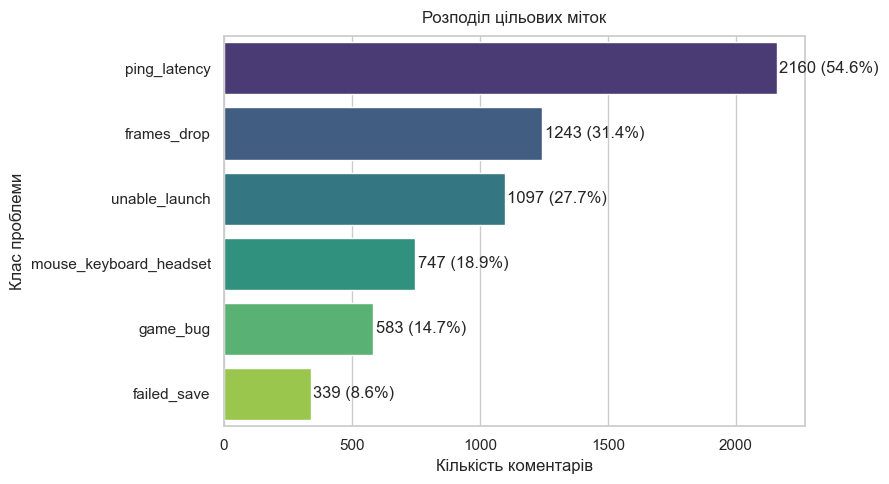

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=counts.values, y=counts.index, palette='viridis', ax=ax)
ax.set_title('Розподіл цільових міток', pad=10)
ax.set_xlabel('Кількість коментарів')
ax.set_ylabel('Клас проблеми')

for i, (count, pct) in enumerate(zip(label_stats["count"], label_stats["percent"])):
    ax.text(count + 10, i, f"{count} ({pct}%)", va="center")

plt.tight_layout()
plt.show()

Розподіл класів є нерівномірним. Найпоширеніша мітка — `ping_latency`, яка зустрічається майже вдвічі частіше за наступний клас. Найменше прикладів мають `game_bug` та `failed_save`, що свідчить про помірний дисбаланс класів. Під час навчання моделей це необхідно враховувати, використовуючи метрики, стійкі до дисбалансу (наприклад, macro-F1), а для класичних моделей — за потреби застосовувати class_weight='balanced'.

### 3.2 Спільна поява міток (co-occurrence)

Оскільки один коментар може містити кілька технічних проблем, перевіримо, які мітки найчастіше зустрічаються разом.

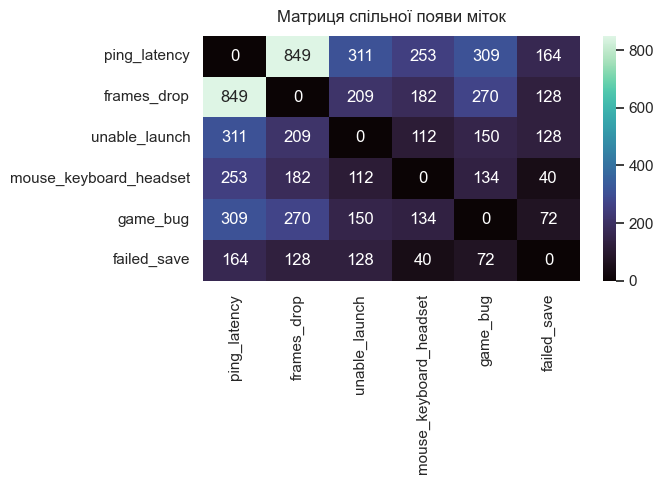

In [20]:
co_matrix = df[LABELS].T.dot(df[LABELS])
np.fill_diagonal(co_matrix.values, 0)   # прибираємо діагональ (клас сам із собою — неінформативно)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='mako', ax=ax)
ax.set_title('Матриця спільної появи міток', pad=10)

plt.tight_layout()
plt.show()

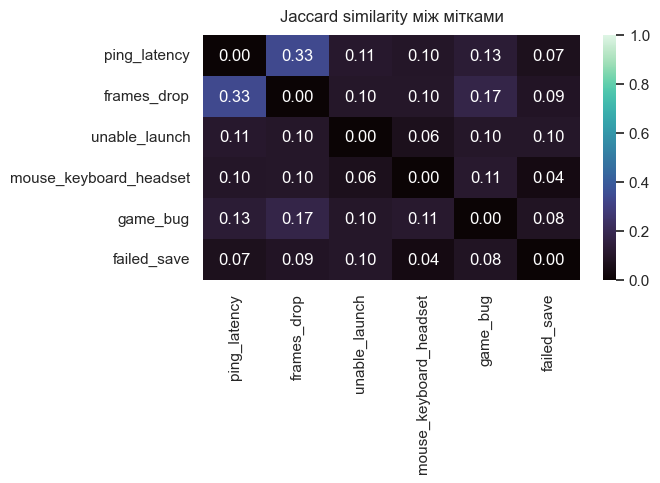

In [21]:
# Матриця Jaccard similarity між цільовими мітками
label_counts = df[LABELS].sum()
co_matrix = df[LABELS].T.dot(df[LABELS])

# Для кожної пари: |A ∪ B| = |A| + |B| - |A ∩ B|
union_matrix = (
    label_counts.values[:, None]
    + label_counts.values[None, :]
    - co_matrix.values
)
jaccard_matrix = pd.DataFrame(
    co_matrix.values / union_matrix,
    index=LABELS,
    columns=LABELS
)
np.fill_diagonal(jaccard_matrix.values, 0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(jaccard_matrix, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1, ax=ax)
ax.set_title("Jaccard similarity між мітками", pad=10)

plt.tight_layout()
plt.show()

Матриця спільної появи показує абсолютну кількість коментарів, у яких дві технічні проблеми згадуються одночасно. Найчастіше разом зустрічаються `ping_latency` та `frames_drop` (849 коментарів), що є логічним, оскільки нестабільне мережеве з’єднання часто супроводжується погіршенням плавності гри.

Матриця Jaccard similarity враховує не лише кількість спільних появ, а й загальну поширеність кожної мітки. Навіть після такої нормалізації саме пара `ping_latency` – `frames_drop` залишається найтісніше пов’язаною (0.33), тоді як більшість інших пар мають значення близько 0.10–0.17, що свідчить про відносно слабкий зв’язок між різними типами проблем.

Отже, хоча окремі комбінації трапляються регулярно, більшість коментарів описують лише одну або дві конкретні технічні проблеми.

### 3.3 Кількість міток на один коментар

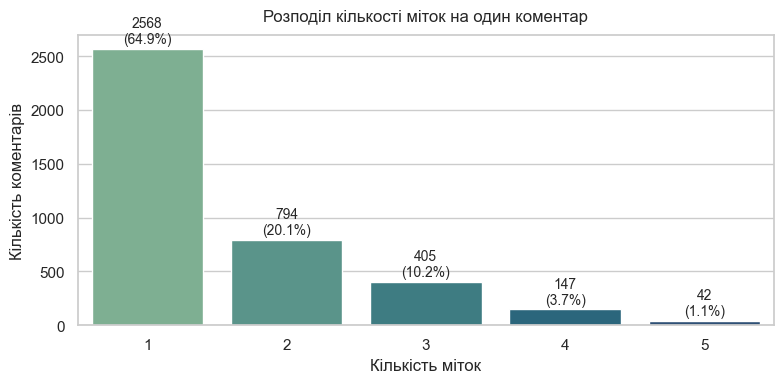

Середня кількість міток на коментар: 1.56


In [22]:
labels_per_comment = df["n_labels"].value_counts().sort_index()
total = len(df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=labels_per_comment.index,
    y=labels_per_comment.values,
    palette="crest",
    ax=ax
)
for i, count in enumerate(labels_per_comment.values):
    percent = count / total * 100
    ax.text(
        i,
        count + 25,
        f'{count}\n({percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Розподіл кількості міток на один коментар', pad=10)
ax.set_xlabel('Кількість міток')
ax.set_ylabel('Кількість коментарів')

plt.tight_layout()
plt.show()

print(f'Середня кількість міток на коментар: {df["n_labels"].mean():.2f}')

Близько 65% коментарів містять лише одну мітку, ще приблизно 20% — дві. Коментарі з трьома і більше технічними проблемами трапляються значно рідше. Середня кількість міток становить 1.56 на коментар, що підтверджує multi-label характер задачі, хоча більшість повідомлень описують одну конкретну проблему.

### 3.4 Розподіл довжини текстів

In [23]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

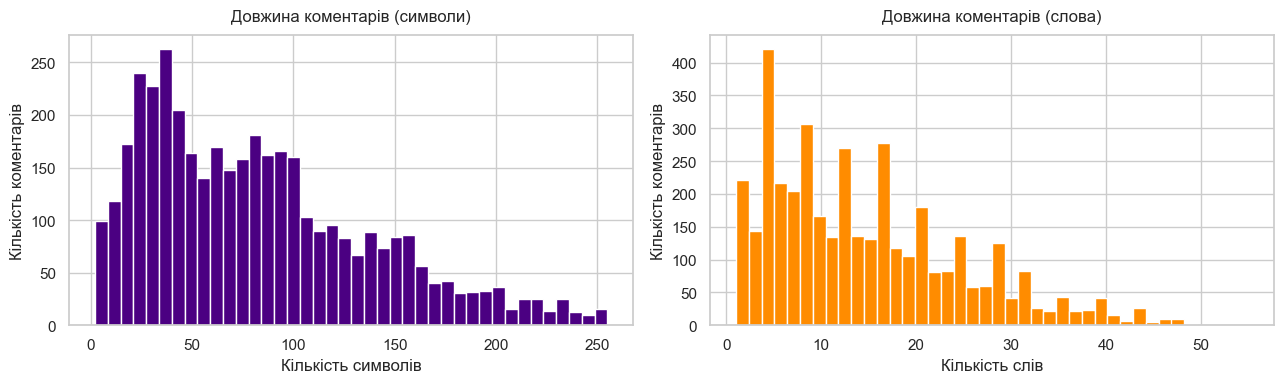

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['text_length'], bins=40, color='indigo')
axes[0].set_title('Довжина коментарів (символи)', pad=10)
axes[0].set_xlabel('Кількість символів')
axes[0].set_ylabel("Кількість коментарів")

axes[1].hist(df['word_count'], bins=40, color='darkorange')
axes[1].set_title('Довжина коментарів (слова)', pad=10)
axes[1].set_xlabel('Кількість слів')
axes[1].set_ylabel("Кількість коментарів")

plt.tight_layout()
plt.show()

In [25]:
print('Статистика довжини (символи):\n')
print(df['text_length'].describe().round(1))

Статистика довжини (символи):

count    3956.0
mean       82.4
std        55.9
min         2.0
25%        36.0
50%        73.0
75%       115.2
max       255.0
Name: text_length, dtype: float64


In [26]:
print("\nСтатистика довжини (слова):\n")
print(df["word_count"].describe().round(1))


Статистика довжини (слова):

count    3956.0
mean       14.7
std        10.2
min         1.0
25%         6.0
50%        13.0
75%        21.0
max        55.0
Name: word_count, dtype: float64


Аналіз довжини текстів показав, що більшість коментарів є короткими: медіанна довжина становить 73 символи (13 слів), а 75% повідомлень містять не більше 115 символів (21 слова). Довгі повідомлення зустрічаються відносно рідко, що свідчить про компактний стиль опису технічних проблем користувачами. Через невеликий обсяг тексту кожен коментар містить обмежену кількість інформації, тому ефективне текстове представлення є важливим фактором для побудови моделі класифікації.

### 3.5 Розподіл мов

Коментарі написані різними мовами. Визначаємо мову бібліотекою `langdetect` — лише для аналізу, самі моделі працюють з текстом мультимовно і без перекладу.

In [27]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0   # щоб визначення мови було детермінованим

In [28]:
df['lang'] = df['text'].apply(safe_detect)

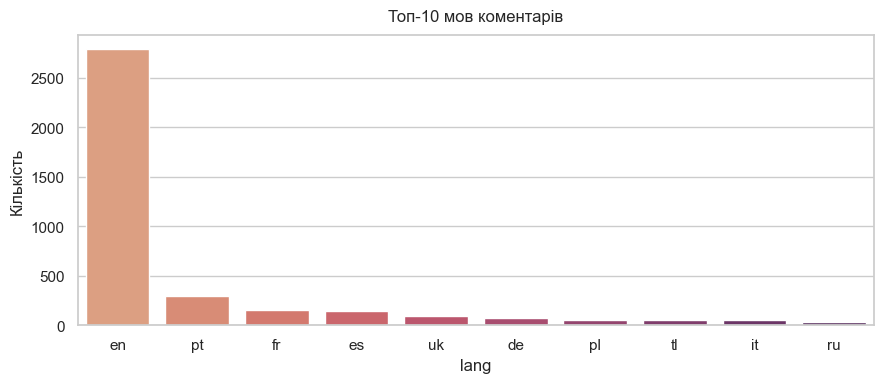

In [29]:
top_lang = df['lang'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=top_lang.index, y=top_lang.values, palette='flare', ax=ax)
ax.set_title('Топ-10 мов коментарів', pad=10)
ax.set_ylabel('Кількість')
plt.tight_layout()
plt.show()

In [30]:
print(top_lang)

lang
en    2791
pt     297
fr     154
es     145
uk      91
de      74
pl      58
tl      50
it      48
ru      33
Name: count, dtype: int64


In [31]:
lang_percent = df["lang"].value_counts(normalize=True).mul(100).round(1)
print(lang_percent.head(10))

lang
en    70.6
pt     7.5
fr     3.9
es     3.7
uk     2.3
de     1.9
pl     1.5
tl     1.3
it     1.2
ru     0.8
Name: proportion, dtype: float64


Хоча англійська мова домінує та становить 70.6% усіх коментарів, проте майже третина повідомлень написана іншими мовами. Найпоширенішими серед них є португальська, французька, іспанська, українська, німецька та ін. Отже, набір даних є мультимовним, тому під час побудови моделей необхідно використовувати методи, здатні ефективно працювати з текстами різними мовами без попереднього перекладу.

### 3.6 Найчастіші слова по класах

Проаналізуємо, які слова характерні для кожного класу — це допомагає зрозуміти, чи взагалі є в текстах явний сигнал про тип проблеми. Розглянемо англомовну частину датасету, оскільки стандартний список стоп-слів CountVectorizer підтримує англійську мову. Мультимовність повного набору даних буде врахована під час вибору моделей.

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

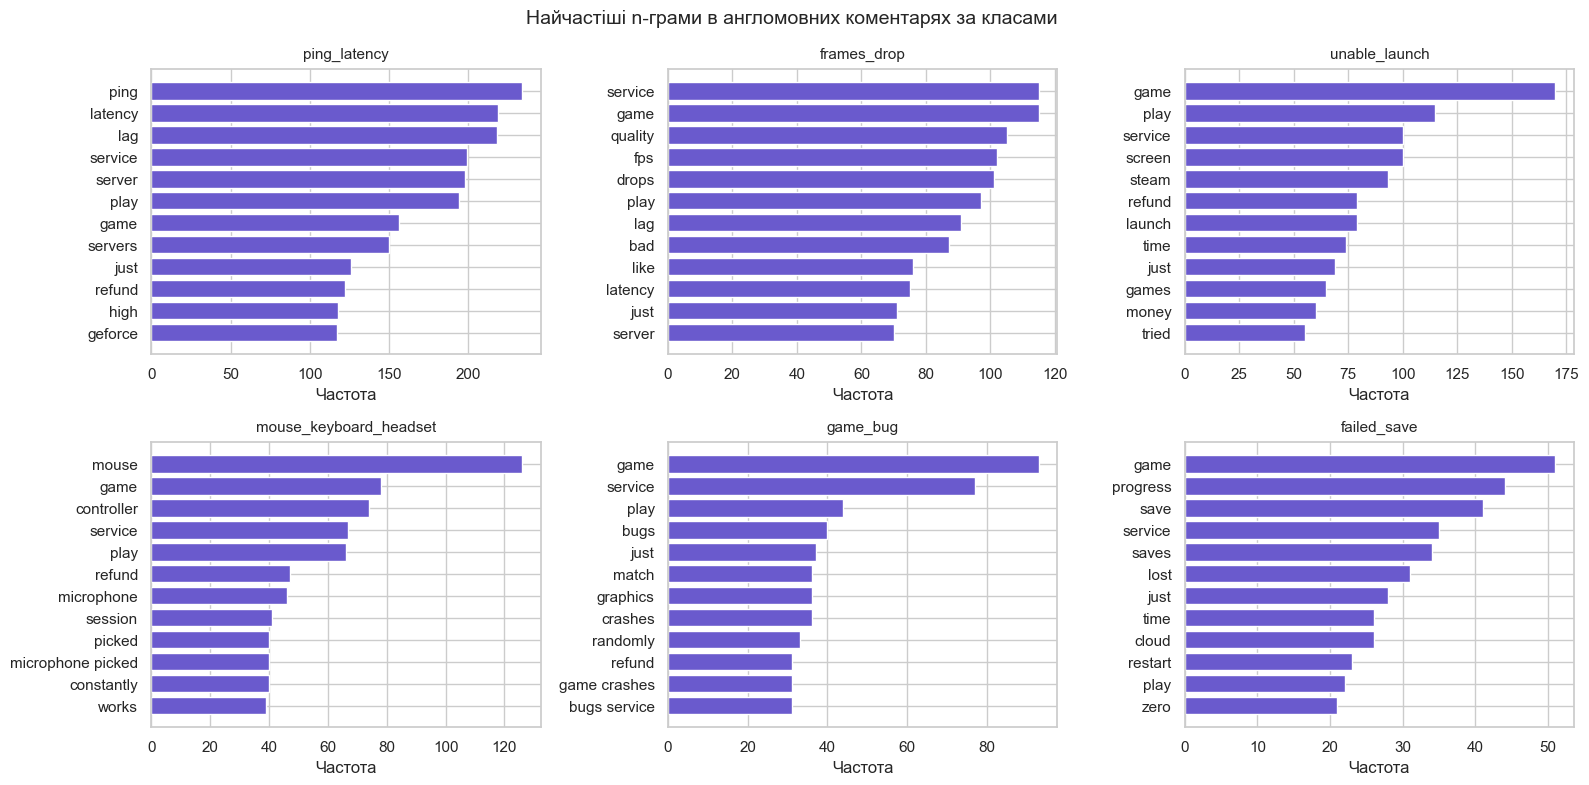

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.ravel(), LABELS):
    subset = df.loc[(df[label] == 1) & (df["lang"] == "en"), "text"]
    vectorizer = CountVectorizer(
        max_features=12,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )
    X_counts = vectorizer.fit_transform(subset)

    frequencies = np.asarray(X_counts.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = frequencies.argsort()[::-1]

    ax.barh(terms[order][::-1], frequencies[order][::-1], color='slateblue')
    ax.set_title(label, fontsize=11, pad=8)
    ax.set_xlabel("Частота")

plt.suptitle("Найчастіші n-грами в англомовних коментарях за класами", fontsize=14)
plt.tight_layout()
plt.show()

Аналіз англомовних коментарів показує наявність тематично релевантної лексики для окремих класів. Для `ping_latency` найчастіше зустрічаються слова *ping, lag, latency, server*; для `frames_drop` — *fps, lag, quality, drops*; для `mouse_keyboard_headset` — *mouse, controller, microphone*; для `failed_save` — *save, progress, lost, restart*. Тобто текст несе явний сигнал про тип проблеми, і задача виглядає розвʼязною для моделей класифікації. Водночас загальні слова на кшталт *game, service, play* зустрічаються в кількох класах і мають меншу дискримінативну цінність.

## 4. Розбиття на train / validation / test

У multi-label задачах звичайна стратифікація через параметр `stratify` у `train_test_split` не підходить, оскільки цільова змінна містить не один клас, а вектор із шести бінарних міток. Тому використаємо iterative-stratified розбиття із бібліотеки `iterative-stratification`, яка намагається зберегти частоту кожної мітки та їхніх комбінацій у підвибірках. Дані розділяємо у співвідношенні, близькому до 70% / 15% / 15%.

In [34]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [35]:
X = df['text'].values
Y = df[LABELS].values

In [36]:
# Крок 1: відділяємо 30% (val + test) від train
splitter_1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, temp_idx = next(splitter_1.split(X, Y))

# Крок 2: ділимо ці 30% навпіл на val і test
splitter_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_STATE)
val_rel, test_rel = next(splitter_2.split(X[temp_idx], Y[temp_idx]))
val_idx, test_idx = temp_idx[val_rel], temp_idx[test_rel]

In [37]:
X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(f'Train: {len(X_train)}')
print(f'Val:   {len(X_val)}')
print(f'Test:  {len(X_test)}')

Train: 2760
Val:   584
Test:  612


In [38]:
# Перевіряємо, що частка кожного класу зберіглась у всіх трьох підвибірках
pd.DataFrame({
    'train': Y_train.mean(0),
    'val': Y_val.mean(0),
    'test': Y_test.mean(0),
}, index=LABELS).round(3)

,train,val,test
ping_latency,0.548,0.555,0.529
frames_drop,0.315,0.320,0.304
unable_launch,0.278,0.283,0.268
mouse_keyboard_headset,0.189,0.192,0.183
game_bug,0.148,0.149,0.144
failed_save,0.086,0.087,0.083


Після розбиття отримано 2760 тренувальних, 584 валідаційних і 612 тестових прикладів, що відповідає співвідношенню, близькому до 70% / 15% / 15%. Частки всіх шести міток у підвибірках залишилися близькими, отже iterative stratification успішно зберегла початковий розподіл класів. Validation-вибірка надалі використовуватиметься для вибору моделей і налаштування порогів, а test-вибірка — лише для фінального незалежного оцінювання.

## 5. Метрики оцінювання

**Основна метрика — macro-F1.** Адже: 
- **micro-F1** об’єднує TP, FP і FN для всіх класів та обчислює одну загальну оцінку, тому на незбалансованих даних результат значною мірою визначається якістю прогнозування поширених класів.
- **macro-F1** спочатку обчислює F1 окремо для кожного класу, а потім усереднює отримані значення з однаковою вагою. Завдяки цьому якість прогнозування рідкісних міток впливає на підсумкову оцінку так само, як і якість поширених.

У датасеті наявний суттєвий дисбаланс: `ping_latency` зустрічається приблизно у 6 разів частіше за `failed_save`. Тому macro-F1 краще відповідає меті проєкту — отримати модель, яка стабільно працює для всіх типів технічних проблем.

Додатково використовуватимемо micro-F1, macro ROC-AUC та macro Average Precision (mAP). Пороги перетворення оцінок моделі на бінарні прогнози підбиратимемо окремо для кожного класу на validation-вибірці шляхом максимізації F1. Вибрані пороги потім без змін застосовуватимуться до test-вибірки. Усі результати складаємо в список `RESULTS`, з якого потім збудуємо підсумкову таблицю експериментів.

In [39]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, classification_report
RESULTS = functions.RESULTS   # складатимемо результат кожного експерименту (список у модулі)
RESULTS.clear()               # щоб повторний запуск не дублював попередні результати

## 6. Baseline-модель

Найпростіша точка відліку — для кожної мітки завжди прогнозувати її найчастіше значення у train-вибірці. Такий baseline не використовує текст і не є повноцінною моделлю, а слугує нижньою межею якості, з якою порівнюватимуться всі наступні підходи.

In [40]:
# Найчастіше значення кожної мітки у train-вибірці
majority_labels = (
    Y_train.mean(axis=0) >= 0.5
).astype(int)

# Для кожного train-прикладу прогнозуємо однаковий вектор
dummy_train = np.tile(
    majority_labels,
    (len(Y_train), 1)
)
# Для кожного validation-прикладу прогнозуємо однаковий вектор
dummy_pred = np.tile(
    majority_labels,
    (len(Y_val), 1)
)

_ = evaluate(name="Baseline (most_frequent)", y_true=Y_train, y_prob=dummy_train, thresholds=0.5, split="train")
_ = evaluate(name="Baseline (most_frequent)", y_true=Y_val, y_prob=dummy_pred, thresholds=0.5, split="val",)

# Перевіряємо, що саме прогнозує baseline
pd.Series(
    majority_labels,
    index=LABELS,
    name="most_frequent_prediction"
)

[Baseline (most_frequent) | train] macro-F1=0.118  micro-F1=0.427  AUC=0.500  mAP=0.261  train_time:None
[Baseline (most_frequent) | val] macro-F1=0.119  micro-F1=0.429  AUC=0.500  mAP=0.264  train_time:None


ping_latency              1
frames_drop               0
unable_launch             0
mouse_keyboard_headset    0
game_bug                  0
failed_save               0
Name: most_frequent_prediction, dtype: int64

Baseline завжди прогнозує найчастіше значення кожної мітки в train-вибірці. У результаті для `ping_latency` він постійно передбачає 1, а для решти п’яти класів — 0. Така стратегія дає macro-F1 ≈ 0.12, оскільки рідкісні класи взагалі не розпізнаються і мають F1, рівний нулю. Отриманий результат використовується як нижня межа якості: повноцінні моделі повинні суттєво перевищити цей показник.

## 7. Модель 1 — TF-IDF + класичні класифікатори

Класичний підхід до NLP: перетворюємо текст у TF-IDF вектори і навчаємо звичайні sklearn-моделі. Використовуємо **word-** і **char-n-грами** одночасно й обʼєднуємо їх в одну матрицю ознак — char-n-грами (`analyzer='char_wb'`) особливо корисні для мультимовного тексту, бо не залежать від токенізації конкретної мови.

Далі порівнюємо три класичні моделі: **Logistic Regression**, **LinearSVC** і **Random Forest**.

In [41]:
import time
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from scipy.special import expit

In [42]:
# Дві окремі TF-IDF векторизації: по словах і по символах, потім склеюємо ознаки разом
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, sublinear_tf=True)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2, sublinear_tf=True)

X_train_word = word_vec.fit_transform(X_train)
X_train_char = char_vec.fit_transform(X_train)
X_train_tfidf = hstack([X_train_word, X_train_char]).tocsr()

X_val_tfidf = hstack([word_vec.transform(X_val), char_vec.transform(X_val)]).tocsr()
X_test_tfidf = hstack([word_vec.transform(X_test), char_vec.transform(X_test)]).tocsr()

print(f'Розмір TF-IDF матриці (train): {X_train_tfidf.shape}')

Розмір TF-IDF матриці (train): (2760, 25089)


Після об’єднання word- та char-n-грам кожен документ описується 25 089 TF-IDF ознаками. Саме ця матриця використовується як вхід для всіх трьох класичних моделей.

`LogisticRegression` і `LinearSVC` за замовчуванням вміють передбачати лише один клас на приклад. Щоб навчити їх передбачати **кілька** міток одночасно, загортаємо кожну модель в `OneVsRestClassifier` — під капотом він тренує окремий бінарний класифікатор на кожен з 6 класів.

In [43]:
# Підбираємо параметр регуляризації C для Logistic Regression (перебір за macro-F1 на val)
best_C, best_f1 = 0.5, -1
for C in [0.5, 1.0, 2.0, 4.0]:
    clf = OneVsRestClassifier(LogisticRegression(C=C, max_iter=2000, class_weight='balanced'))
    clf.fit(X_train_tfidf, Y_train)
    val_prob = clf.predict_proba(X_val_tfidf)
    f = f1_score(Y_val, (val_prob >= tune_thresholds(Y_val, val_prob)).astype(int),
                 average='macro', zero_division=0)
    print(f'C={C}: val macro-F1={f:.3f}')
    if f > best_f1:
        best_f1, best_C = f, C

print(f'\nНайкраще C = {best_C}')

C=0.5: val macro-F1=0.632
C=1.0: val macro-F1=0.631
C=2.0: val macro-F1=0.628
C=4.0: val macro-F1=0.627

Найкраще C = 0.5


In [44]:
# Навчаємо фінальну модель TF-IDF + LogReg з найкращим C
t0 = time.time()
tfidf_lr = OneVsRestClassifier(LogisticRegression(C=best_C, max_iter=2000, class_weight='balanced'))
tfidf_lr.fit(X_train_tfidf, Y_train)
train_time_lr = time.time() - t0

val_prob_lr = tfidf_lr.predict_proba(X_val_tfidf)
th_lr = tune_thresholds(Y_val, val_prob_lr)

_ = evaluate('TF-IDF + LogReg', Y_train, tfidf_lr.predict_proba(X_train_tfidf), th_lr, split='train')
_ = evaluate('TF-IDF + LogReg', Y_val, val_prob_lr, th_lr,
         params=f'word(1,2)+char(2,5), C={best_C}, balanced', train_time=round(train_time_lr, 1), split='val')

[TF-IDF + LogReg | train] macro-F1=0.818  micro-F1=0.849  AUC=0.964  mAP=0.922  train_time:None
[TF-IDF + LogReg | val] macro-F1=0.632  micro-F1=0.701  AUC=0.813  mAP=0.695  train_time:0.4


In [45]:
# TF-IDF + LinearSVC
t0 = time.time()
tfidf_svc = OneVsRestClassifier(LinearSVC(C=1.0, class_weight='balanced'))
tfidf_svc.fit(X_train_tfidf, Y_train)
train_time_svc = time.time() - t0

# LinearSVC не має predict_proba, тому застосовуємо сигмоїдальне перетворення до значень decision_function, щоб отримати оцінки у діапазоні [0,1]
val_scores_svc = expit(tfidf_svc.decision_function(X_val_tfidf))
th_svc = tune_thresholds(Y_val, val_scores_svc)

_ = evaluate('TF-IDF + LinearSVC', Y_train, expit(tfidf_svc.decision_function(X_train_tfidf)), th_svc, split='train')
_ = evaluate('TF-IDF + LinearSVC', Y_val, val_scores_svc, th_svc,
         params='word+char, C=1.0, balanced', train_time=round(train_time_svc, 1), split='val')

[TF-IDF + LinearSVC | train] macro-F1=0.934  micro-F1=0.946  AUC=0.998  mAP=0.996  train_time:None
[TF-IDF + LinearSVC | val] macro-F1=0.613  micro-F1=0.657  AUC=0.800  mAP=0.682  train_time:0.7


**Додаткова модель — Random Forest.** На відміну від `LogisticRegression` та `LinearSVC`, sklearn-реалізація `RandomForestClassifier` підтримує multi-output класифікацію, тому OneVsRestClassifier тут не потрібен. Тут теж робимо невеликий перебір гіперпараметрів (кількість дерев і мінімальний розмір листа) за macro-F1 на validation.

In [46]:
# Підбір гіперпараметрів Random Forest (перебір по сітці за macro-F1 на val)
best_rf_params, best_rf_f1 = None, -1
for n_est in [200, 300]:
    for min_leaf in [1, 2]:
        rf = RandomForestClassifier(n_estimators=n_est, min_samples_leaf=min_leaf,
                                    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_train_tfidf, Y_train)
        vp = np.column_stack([p[:, 1] for p in rf.predict_proba(X_val_tfidf)])
        f = f1_score(Y_val, (vp >= tune_thresholds(Y_val, vp)).astype(int),
                     average='macro', zero_division=0)
        print(f'n_estimators={n_est}, min_samples_leaf={min_leaf}: val macro-F1={f:.3f}')
        if f > best_rf_f1:
            best_rf_f1, best_rf_params = f, {'n_estimators': n_est, 'min_samples_leaf': min_leaf}

print(f'\nНайкращі параметри RF: {best_rf_params}')

n_estimators=200, min_samples_leaf=1: val macro-F1=0.643
n_estimators=200, min_samples_leaf=2: val macro-F1=0.621
n_estimators=300, min_samples_leaf=1: val macro-F1=0.650
n_estimators=300, min_samples_leaf=2: val macro-F1=0.622

Найкращі параметри RF: {'n_estimators': 300, 'min_samples_leaf': 1}


In [47]:
# Навчаємо фінальний Random Forest з найкращими параметрами
t0 = time.time()
tfidf_rf = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
tfidf_rf.fit(X_train_tfidf, Y_train)
train_time_rf = time.time() - t0

# predict_proba для multi-label повертає список з 6 матриць [n_samples, 2] — беремо ймовірність класу 1
val_prob_rf = np.column_stack([p[:, 1] for p in tfidf_rf.predict_proba(X_val_tfidf)])
th_rf = tune_thresholds(Y_val, val_prob_rf)
train_prob_rf = np.column_stack([p[:, 1] for p in tfidf_rf.predict_proba(X_train_tfidf)])

_ = evaluate('TF-IDF + RandomForest', Y_train, train_prob_rf, th_rf, split='train')
_ = evaluate('TF-IDF + RandomForest', Y_val, val_prob_rf, th_rf,
         params=f"n={best_rf_params['n_estimators']}, leaf={best_rf_params['min_samples_leaf']}, balanced",
         train_time=round(train_time_rf, 1), split='val')

[TF-IDF + RandomForest | train] macro-F1=0.989  micro-F1=0.991  AUC=1.000  mAP=0.998  train_time:None
[TF-IDF + RandomForest | val] macro-F1=0.650  micro-F1=0.694  AUC=0.810  mAP=0.658  train_time:2.3


Усі три класичні моделі суттєво перевершили baseline. **Logistic Regression** продемонструвала найкращий баланс між якістю, швидкістю навчання та здатністю до узагальнення. **LinearSVC** показала дещо нижчу якість і більш виражене перенавчання. **Random Forest** досяг найкращого результату на validation серед **TF-IDF** моделей, однак майже ідеальні метрики на train свідчать про сильне перенавчання. Отже, **Random Forest** є найкращою класичною моделлю за якістю на validation, тоді як **Logistic Regression** виглядає найбільш збалансованим і практичним варіантом.

## 8. Модель 2 — мультимовні ембединги + класифікатор

На відміну від попереднього підходу, де використовувався **TF-IDF**, тут кожен текст представляється готовим мультимовним семантичним ембедингом, отриманим за допомогою моделі `paraphrase-multilingual-MiniLM-L12-v2` (бібліотека `sentence-transformers`). Енкодер залишається замороженим (без донавчання), а поверх 384-вимірних ембедингів навчаються класичні класифікатори — **Logistic Regression** та **XGBoost**.

In [48]:
import torch
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier

from transformers.utils import logging
logging.set_verbosity_error()

In [49]:
# Обираємо найкращий доступний пристрій: NVIDIA GPU (CUDA) → Apple GPU (MPS) → CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Пристрій: {device}")

Пристрій: mps


In [50]:
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [51]:
# Кодуємо тексти у щільні вектори (нормалізуємо — так зручніше для лінійних моделей)
E_train = encoder.encode(list(X_train), batch_size=64, normalize_embeddings=True, show_progress_bar=False)
E_val = encoder.encode(list(X_val), batch_size=64, normalize_embeddings=True, show_progress_bar=False)
E_test = encoder.encode(list(X_test), batch_size=64, normalize_embeddings=True, show_progress_bar=False)

print(f'Розмір ембедингів train: {E_train.shape}')

Розмір ембедингів train: (2760, 384)


In [52]:
# Ембединги + Logistic Regression
t0 = time.time()
emb_lr = OneVsRestClassifier(LogisticRegression(C=2.0, max_iter=3000, class_weight='balanced'))
emb_lr.fit(E_train, Y_train)
train_time_emb_lr = time.time() - t0

val_prob_emb = emb_lr.predict_proba(E_val)
th_emb_lr = tune_thresholds(Y_val, val_prob_emb)

_ = evaluate('Embed(MiniLM) + LogReg', Y_train, emb_lr.predict_proba(E_train), th_emb_lr, split='train')
_ = evaluate('Embed(MiniLM) + LogReg', Y_val, val_prob_emb, th_emb_lr,
         params='C=2, balanced', train_time=round(train_time_emb_lr, 1), split='val')

[Embed(MiniLM) + LogReg | train] macro-F1=0.615  micro-F1=0.693  AUC=0.859  mAP=0.692  train_time:None
[Embed(MiniLM) + LogReg | val] macro-F1=0.623  micro-F1=0.688  AUC=0.811  mAP=0.652  train_time:0.0


In [53]:
# Підбір гіперпараметрів XGBoost (перебір по сітці за macro-F1 на val)
best_xgb_params, best_xgb_f1 = None, -1
for depth in [4, 6]:
    for lr in [0.1, 0.2]:
        xgb = OneVsRestClassifier(XGBClassifier(
            n_estimators=300, max_depth=depth, learning_rate=lr,
            subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
            n_jobs=1, tree_method='hist'))
        xgb.fit(E_train, Y_train)
        vp = xgb.predict_proba(E_val)
        f = f1_score(Y_val, (vp >= tune_thresholds(Y_val, vp)).astype(int),
                     average='macro', zero_division=0)
        print(f'max_depth={depth}, lr={lr}: val macro-F1={f:.3f}')
        if f > best_xgb_f1:
            best_xgb_f1, best_xgb_params = f, {'max_depth': depth, 'learning_rate': lr}

print(f'\nНайкращі параметри XGB: {best_xgb_params}')

max_depth=4, lr=0.1: val macro-F1=0.624
max_depth=4, lr=0.2: val macro-F1=0.598
max_depth=6, lr=0.1: val macro-F1=0.627
max_depth=6, lr=0.2: val macro-F1=0.613

Найкращі параметри XGB: {'max_depth': 6, 'learning_rate': 0.1}


In [54]:
# Навчаємо фінальний XGBoost з найкращими параметрами
t0 = time.time()
emb_xgb = OneVsRestClassifier(XGBClassifier(
    n_estimators=300, max_depth=best_xgb_params['max_depth'],
    learning_rate=best_xgb_params['learning_rate'],
    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
    n_jobs=1, tree_method='hist'))
emb_xgb.fit(E_train, Y_train)
train_time_emb_xgb = time.time() - t0

val_prob_xgb = emb_xgb.predict_proba(E_val)
th_emb_xgb = tune_thresholds(Y_val, val_prob_xgb)

_ = evaluate('Embed(MiniLM) + XGBoost', Y_train, emb_xgb.predict_proba(E_train), th_emb_xgb, split='train')
_ = evaluate('Embed(MiniLM) + XGBoost', Y_val, val_prob_xgb, th_emb_xgb,
         params=f"n=300, depth={best_xgb_params['max_depth']}, lr={best_xgb_params['learning_rate']}",
         train_time=round(train_time_emb_xgb, 1), split='val')

[Embed(MiniLM) + XGBoost | train] macro-F1=1.000  micro-F1=1.000  AUC=1.000  mAP=1.000  train_time:None
[Embed(MiniLM) + XGBoost | val] macro-F1=0.627  micro-F1=0.699  AUC=0.805  mAP=0.653  train_time:32.8


Використання готових мультимовних ембедингів забезпечило якість, близьку до класичних **TF-IDF** підходів, без необхідності вручну підбирати n-грами. Найкращі результати для моделі **XGBoost** були отримані після підбору її гіперпараметрів.

Аналіз результатів на train і validation показав суттєву різницю у здатності моделей до узагальнення. **Embed(MiniLM) + Logistic Regression** продемонструвала стабільну якість на обох вибірках і практично не виявила ознак перенавчання, що свідчить про хорошу узагальнювальну здатність ембедингів у поєднанні з лінійним класифікатором. **Embed(MiniLM) + XGBoost**, навпаки, показала виражене перенавчання: модель дуже добре запам’ятовувала тренувальні дані, але це не призвело до покращення результатів на validation. Отже, для готових мультимовних ембедингів використання простішого лінійного класифікатора виявилося більш стабільним і ефективним, тоді як застосування складнішої моделі не забезпечило додаткового приросту якості.

## 9. Модель 3 — Fine-tuned multilingual DistilBERT

На відміну від попередніх підходів, тут донавчаємо (fine-tune) весь мультимовний трансформер **DistilBERT** під задачу multi-label класифікації. До моделі додається класифікаційна голова на 6 класів із sigmoid-активацією, а навчання виконується власним циклом у `PyTorch`. Для компенсації дисбалансу класів використовуємо `BCEWithLogitsLoss` із `pos_weight`, а найкращий стан моделі зберігаємо за значенням validation macro-F1.

In [55]:
import random
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [56]:
# Гіперпараметри та фіксація сідів
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CKPT = 'distilbert-base-multilingual-cased'
MAX_LEN = 64        # тексти короткі — 64 токенів вистачає з запасом
BATCH_SIZE = 16
EPOCHS = 5
LR_GRID = [2e-5, 5e-5, 8e-5]   # мінімальний підбір lr (найважливіший гіперпараметр для fine-tuning)

print(f'Модель: {CKPT} | пристрій: {device}')

Модель: distilbert-base-multilingual-cased | пристрій: mps


In [57]:
tokenizer = AutoTokenizer.from_pretrained(CKPT)

def encode_texts(texts):
    enc = tokenizer(list(texts), truncation=True, padding='max_length',
                     max_length=MAX_LEN, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

train_ids, train_mask = encode_texts(X_train)
val_ids, val_mask = encode_texts(X_val)
test_ids, test_mask = encode_texts(X_test)

In [58]:
train_ds = TensorDataset(train_ids, train_mask, torch.tensor(Y_train, dtype=torch.float32))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [59]:
# Функція створює свіжу модель DistilBERT (щоб кожен lr стартував з однакового стану)
def build_bert():
    torch.manual_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(
        CKPT, num_labels=len(LABELS), 
        problem_type='multi_label_classification',
        ignore_mismatched_sizes=True
    ).to(device)

In [60]:
# Компенсація дисбалансу класів через pos_weight у функції втрат
pos = Y_train.sum(0)
neg = len(Y_train) - pos
pos_weight = torch.tensor(neg / np.clip(pos, 1, None), dtype=torch.float32).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [61]:
# Рахує ймовірності (sigmoid від логітів) батчами, щоб не переповнити памʼять
def bert_predict(ids, mask, batch_size=64):
    bert_model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(ids), batch_size):
            batch_ids = ids[i:i + batch_size].to(device)
            batch_mask = mask[i:i + batch_size].to(device)
            logits = bert_model(input_ids=batch_ids, attention_mask=batch_mask).logits
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(probs)

In [62]:
# Тренує DistilBERT із заданим lr; повертає найкращий (за val macro-F1) стан і його скор
def train_bert(lr):
    global bert_model
    bert_model = build_bert()
    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=lr, weight_decay=0.01)
    best_f1, best_state = -1, None

    for epoch in range(1, EPOCHS + 1):
        bert_model.train()
        total_loss = 0.0
        for ids, mask, y in train_dl:
            optimizer.zero_grad()
            logits = bert_model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
            loss = loss_fn(logits, y.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_prob = bert_predict(val_ids, val_mask)
        val_f1 = f1_score(Y_val, (val_prob >= tune_thresholds(Y_val, val_prob)).astype(int),
                          average='macro', zero_division=0)
        print(f'  lr={lr:.0e} | епоха {epoch}: loss={total_loss / len(train_dl):.3f}  val macro-F1={val_f1:.3f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in bert_model.state_dict().items()}

    return best_f1, best_state

In [63]:
# Підбір learning rate за val macro-F1 (кожен lr — окреме тренування)
t0 = time.time()
best_lr, best_bert_f1, best_bert_state = None, -1, None
for lr in LR_GRID:
    f1, state = train_bert(lr)
    print(f'lr={lr:.0e}: найкращий val macro-F1={f1:.3f}\n')
    if f1 > best_bert_f1:
        best_bert_f1, best_bert_state, best_lr = f1, state, lr

bert_time = time.time() - t0
print(f'Найкращий lr={best_lr:.0e} | val macro-F1={best_bert_f1:.3f} | загальний час гриду: {bert_time:.1f} с')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  lr=2e-05 | епоха 1: loss=0.968  val macro-F1=0.620
  lr=2e-05 | епоха 2: loss=0.769  val macro-F1=0.654
  lr=2e-05 | епоха 3: loss=0.638  val macro-F1=0.655
  lr=2e-05 | епоха 4: loss=0.529  val macro-F1=0.660
  lr=2e-05 | епоха 5: loss=0.440  val macro-F1=0.656
lr=2e-05: найкращий val macro-F1=0.660



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  lr=5e-05 | епоха 1: loss=0.912  val macro-F1=0.642
  lr=5e-05 | епоха 2: loss=0.711  val macro-F1=0.655
  lr=5e-05 | епоха 3: loss=0.560  val macro-F1=0.667
  lr=5e-05 | епоха 4: loss=0.451  val macro-F1=0.659
  lr=5e-05 | епоха 5: loss=0.372  val macro-F1=0.636
lr=5e-05: найкращий val macro-F1=0.667



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  lr=8e-05 | епоха 1: loss=0.921  val macro-F1=0.643
  lr=8e-05 | епоха 2: loss=0.731  val macro-F1=0.638
  lr=8e-05 | епоха 3: loss=0.606  val macro-F1=0.681
  lr=8e-05 | епоха 4: loss=0.490  val macro-F1=0.642
  lr=8e-05 | епоха 5: loss=0.395  val macro-F1=0.642
lr=8e-05: найкращий val macro-F1=0.681

Найкращий lr=8e-05 | val macro-F1=0.681 | загальний час гриду: 862.2 с


In [64]:
# Беремо найкращу конфігурацію (lr + стан найкращої епохи) і завантажуємо її у свіжу модель
bert_model = build_bert()
bert_model.load_state_dict(best_bert_state)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

<All keys matched successfully>

In [65]:
bert_val_prob = bert_predict(val_ids, val_mask)
th_bert = tune_thresholds(Y_val, bert_val_prob)
evaluate('BERT (distil-mBERT)', Y_train, bert_predict(train_ids, train_mask), th_bert, split='train')
_ = evaluate('BERT (distil-mBERT)', Y_val, bert_val_prob, th_bert,
         params=f'lr={best_lr:.0e} (grid), ep={EPOCHS}, maxlen={MAX_LEN}, pos_weight',
         train_time=round(bert_time, 1), split='val')

[BERT (distil-mBERT) | train] macro-F1=0.808  micro-F1=0.818  AUC=0.940  mAP=0.889  train_time:None
[BERT (distil-mBERT) | val] macro-F1=0.681  micro-F1=0.717  AUC=0.828  mAP=0.727  train_time:862.2


Для **DistilBERT** було проведено підбір гіперпараметра `learning rate`. Кожна конфігурація навчалася окремо, а найкращий стан моделі зберігався за значенням validation macro-F1. За результатами експерименту було обрано конфігурацію, яка продемонструвала найкращу якість на validation-вибірці.

Порівняння результатів на train і validation свідчить про помірне перенавчання моделі, однак воно є значно менш вираженим, ніж у деревних ансамблів. Це підтверджує кращу здатність трансформера до узагальнення та ефективної роботи з новими даними.

Серед усіх протестованих підходів **fine-tuned DistilBERT** продемонстрував найкращий результат на validation-вибірці. Це підтверджує, що контекстні мультимовні представлення є найбільш ефективними для класифікації коротких різномовних коментарів, оскільки краще враховують семантику тексту, ніж класичні **TF-IDF** представлення або готові **sentence-ембединги**.

Недоліком моделі залишається висока обчислювальна вартість навчання порівняно з класичними методами. Водночас отриманий приріст якості виправдовує ці витрати, якщо пріоритетом є максимальна точність класифікації.

## 10. Модель 4 — LLM-класифікація через OpenAI API (zero-shot)

У цьому підході не навчаємо окремий класифікатор на тренувальній вибірці, а використовуємо готову велику мовну модель через **OpenAI** API. Модель отримує текст коментаря та текстові описи шести класів і в режимі zero-shot повертає всі релевантні мітки.

На відміну від попередніх підходів, тут немає етапу навчання моделі або підбору числових порогів. Якість класифікації залежить насамперед від можливостей LLM, формулювання промпту та описів класів.

In [66]:
from openai import OpenAI

In [67]:
creds = json.load(open('../creds.json'))
client = OpenAI(api_key=creds['OPENAI_API_KEY'])
LLM_MODEL = 'gpt-4o-mini'

In [68]:
# Опис класів для промпту (англійською, бо на вхід моделі йде мультимовний текст)
LABEL_DESC = {
    'ping_latency': (
        'Network-delay problems during cloud gaming, including high ping, '
        'input delay, latency, lag caused by connection quality, or distant servers.'
    ),
    'frames_drop': (
        'Poor visual or streaming performance, including low FPS, frame drops, '
        'stuttering, freezing, or an unstable video stream.'
    ),
    'unable_launch': (
        'The user cannot start, open, load, connect to, or enter the game or service.'
    ),
    'mouse_keyboard_headset': (
        'Problems with input or peripheral devices, including mouse, keyboard, '
        'controller, microphone, headset, or devices not being detected.'
    ),
    'game_bug': (
        'A software defect occurring after the game has launched, such as glitches, '
        'in-game crashes, broken mechanics, graphics bugs, or unexpected errors.'
    ),
    'failed_save': (
        'The game progress or save data is lost, not stored, not synchronized, '
        'or unavailable through cloud saving.'
    )
}

SYSTEM_PROMPT = (
    'You classify short user complaints (any language) left when they cancel a cloud-gaming '
    'subscription. Assign ALL applicable technical-issue labels. Labels and meaning:\n'
    + '\n'.join(f'- {k}: {v}' for k, v in LABEL_DESC.items())
    + '\nReturn ONLY a JSON object: {"labels": [<subset of the label names>]}. '
      'If none clearly applies, pick the single most likely one. Do not invent labels.'
)

In [69]:
# Кеш передбачень LLM, щоб не викликати API повторно на вже класифікованих текстах
# USE_CACHE = False — змусити LLM викликатися наживо (повільніше й платно, але видно реальні виклики API)
USE_CACHE = True

CACHE_DIR = Path('../cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / f'llm_preds_{LLM_MODEL}.json'
llm_cache = json.load(open(CACHE_PATH)) if (USE_CACHE and CACHE_PATH.exists()) else {}

print(f'USE_CACHE={USE_CACHE} | у кеші передбачень: {len(llm_cache)}')

USE_CACHE=True | у кеші передбачень: 1196


In [70]:
# Класифікує один коментар через API (з кешем, якщо USE_CACHE=True)
def llm_classify(text):
    if USE_CACHE and text in llm_cache:
        return llm_cache[text]
    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL, temperature=0,
            response_format={'type': 'json_object'},
            messages=[{'role': 'system', 'content': SYSTEM_PROMPT},
                      {'role': 'user', 'content': text}])
        out = json.loads(resp.choices[0].message.content)
        labels = [l for l in out.get('labels', []) if l in LABELS]
    except Exception as e:
        print(f'Помилка виклику API ({e}), лишаємо коментар без міток')
        labels = []
    if USE_CACHE:
        llm_cache[text] = labels
    return labels


In [71]:
# Класифікуємо validation (з USE_CACHE=True — з кешу, інакше — реальні виклики API)
t0 = time.time()
llm_val_labels = []
for i, text in enumerate(X_val):
    llm_val_labels.append(llm_classify(text))
    if (i + 1) % 200 == 0:
        print(f'  оброблено {i + 1}/{len(X_val)}')

if USE_CACHE:
    json.dump(llm_cache, open(CACHE_PATH, 'w'))
llm_time = time.time() - t0

llm_val_pred = labels_to_matrix(llm_val_labels)
# LLM одразу видає 0/1, а не ймовірності — тому передаємо як "ймовірності" з порогом 0.5
_ = evaluate(f'LLM ({LLM_MODEL})', Y_val, llm_val_pred.astype(float), 0.5,
         params='zero-shot, temperature=0', train_time=round(llm_time, 1), split='val')

  оброблено 200/584
  оброблено 400/584
[LLM (gpt-4o-mini) | val] macro-F1=0.660  micro-F1=0.690  AUC=0.757  mAP=0.576  train_time:0.0


Для LLM-класифікації через **OpenAI API** (zero-shot) модель не донавчалася на навчальній вибірці, а виконувала класифікацію лише на основі текстового промпта та знань, отриманих під час попереднього навчання. Тому процес навчання був відсутній, а оцінювання проводилося лише на validation-вибірці.

Незважаючи на відсутність fine-tuning, модель продемонструвала конкурентний рівень якості. Вона перевершила всі класичні підходи та поступилася лише спеціально донавченому трансформеру, що свідчить про високий потенціал сучасних великих мовних моделей навіть у режимі zero-shot.

Отримані результати підтверджують, що великі мовні моделі вже мають глибоке розуміння семантики тексту й можуть ефективно виконувати multi-label класифікацію без додаткового навчання. Водночас використання LLM через API має низку практичних обмежень: залежність від зовнішнього сервісу, вартість обробки великих обсягів даних, вищу затримку відповіді та менший контроль над моделлю порівняно з локальним fine-tuning.

Отже, **LLM** є дуже сильним базовим рішенням, особливо коли відсутня розмічена навчальна вибірка або потрібно швидко побудувати робочий прототип. Проте якщо доступні навчальні дані та є можливість виконати донавчання, **fine-tuned DistilBERT** є більш доцільним вибором, оскільки забезпечує вищу якість класифікації та може використовуватися локально без залежності від зовнішнього API.

## 11. Порівняння моделей на validation (вибір фінальної моделі)

In [72]:
# Широка таблиця train vs val (macro-F1)
res_df = pd.DataFrame(RESULTS)
wide_tv = res_df.pivot_table(index='model', columns='split', values='macro_f1', aggfunc='last')
train_time = res_df[res_df['split'] == 'val'].set_index('model')['train_time_s']
wide_tv = wide_tv[['train', 'val']].join(train_time.rename('train time, s'))
wide_tv.sort_values('val', ascending=False).round(3)

,train,val,"train time, s"
model,,,
BERT (distil-mBERT),0.808,0.681,862.2
LLM (gpt-4o-mini),NaN,0.660,0.0
TF-IDF + RandomForest,0.989,0.650,2.3
TF-IDF + LogReg,0.818,0.632,0.4
Embed(MiniLM) + XGBoost,1.000,0.627,32.8
Embed(MiniLM) + LogReg,0.615,0.623,0.0
TF-IDF + LinearSVC,0.934,0.613,0.7
Baseline (most_frequent),0.118,0.119,NaN


* Примітка: для BERT вказано час усього перебору learning rate (3 окремих тренування по 5 епох) - одна конфігурація займає приблизно 300 с.

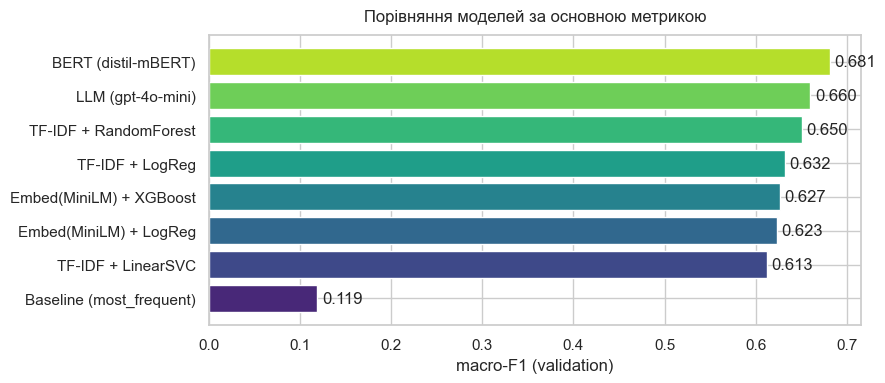

In [73]:
val_res = res_df[res_df['split'] == 'val'].sort_values('macro_f1')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(val_res['model'], val_res['macro_f1'],
                color=sns.color_palette('viridis', len(val_res)))
for b, v in zip(bars, val_res['macro_f1']):
    ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center')
ax.set_xlabel('macro-F1 (validation)')
ax.set_title('Порівняння моделей за основною метрикою', pad=10)
plt.tight_layout()
plt.show()

За результатами порівняння моделей на validation-вибірці найкращу якість продемонстрував **fine-tuned DistilBERT**. Друге місце посіла **LLM-класифікація (zero-shot)**, яка показала конкурентний результат навіть без додаткового навчання. Найкращою серед класичних підходів стала модель **TF-IDF + Random Forest**.

Отримані результати свідчать, що донавчання мультимовного трансформера дозволило найкраще адаптувати модель до специфіки задачі multi-label класифікації коментарів. Незважаючи на відносно невелику перевагу над іншими підходами, саме **DistilBERT** продемонстрував найкращу здатність до узагальнення на validation-вибірці.

Водночас необхідно враховувати і обчислювальні витрати. Навчання трансформерної моделі разом із підбором гіперпараметрів потребує значно більше часу, ніж класичні алгоритми. Проте для цієї роботи основним пріоритетом була максимальна якість класифікації, тому збільшення часу навчання є виправданим.

Отже, для фінального оцінювання на test-вибірці було обрано саме **fine-tuned DistilBERT**, оскільки він продемонстрував найкраще значення основної метрики (macro-F1) серед усіх протестованих підходів і забезпечив найкращий баланс між якістю класифікації та здатністю моделі узагальнювати дані.

## 12. Оцінка фінальної моделі на test

Модель на test оцінюємо один раз, після вибору на validation — інакше порівняння на test усіх моделей означало б витік (ми б обирали під тестову вибірку). Тому тут рахуємо test лише для фінальної обраної моделі **DistilBERT**.

In [74]:
bert_test_prob = bert_predict(test_ids, test_mask)
_ = evaluate('BERT (distil-mBERT)', Y_test, bert_test_prob, th_bert,
         params='test з val-порогами', train_time=round(bert_time, 1), split='test')

[BERT (distil-mBERT) | test] macro-F1=0.620  micro-F1=0.678  AUC=0.817  mAP=0.685  train_time:862.2


In [75]:
# Підсумкова таблиця експериментів: Train / Val / Test (macro-F1) + параметри та час
res_df = pd.DataFrame(RESULTS)
macro = res_df.pivot_table(index='model', columns='split', values='macro_f1', aggfunc='last')
meta = res_df[res_df['split'] == 'val'].set_index('model')[['params', 'train_time_s']]
exp_table = meta.join(macro)
for col in ['train', 'val', 'test']:
    if col not in exp_table.columns:
        exp_table[col] = np.nan
exp_table = exp_table[['params', 'train', 'val', 'test', 'train_time_s']].sort_values('val', ascending=False)
exp_table.columns = ['Parameters', 'Train', 'Val', 'Test', 'Train time, s']
exp_table.round(3).fillna('–')

,Parameters,Train,Val,Test,"Train time, s"
model,,,,,
BERT (distil-mBERT),"lr=8e-05 (grid), ep=5, maxlen=64, pos_weight",0.808,0.681,0.62,862.2
LLM (gpt-4o-mini),"zero-shot, temperature=0",–,0.660,–,0.0
TF-IDF + RandomForest,"n=300, leaf=1, balanced",0.989,0.650,–,2.3
TF-IDF + LogReg,"word(1,2)+char(2,5), C=0.5, balanced",0.818,0.632,–,0.4
Embed(MiniLM) + XGBoost,"n=300, depth=6, lr=0.1",1.0,0.627,–,32.8
Embed(MiniLM) + LogReg,"C=2, balanced",0.615,0.623,–,0.0
TF-IDF + LinearSVC,"word+char, C=1.0, balanced",0.934,0.613,–,0.7
Baseline (most_frequent),,0.118,0.119,–,–


* Примітка: для BERT вказано час усього перебору learning rate (3 окремих тренування по 5 епох) - одна конфігурація займає приблизно 300 с.

Після вибору фінальної моделі за результатами validation-вибірки було проведено її одноразову оцінку на незалежній test-вибірці, яка не використовувалася під час навчання чи підбору гіперпараметрів. Це дозволило отримати об’єктивну оцінку здатності моделі узагальнювати нові дані.

Результати на test-вибірці підтвердили, що fine-tuned DistilBERT успішно переносить набуті закономірності на раніше невідомі приклади. Незважаючи на певне зниження значень метрик порівняно з validation-вибіркою, таке зниження є очікуваним і свідчить про реалістичну оцінку якості моделі, а не про її переналаштування під конкретну вибірку.

Отримані результати підтверджують, що обрана модель має добру здатність до узагальнення та може бути використана для автоматичної multi-label класифікації нових коментарів. Використання попередньо навченого мультимовного трансформера разом із донавчанням на предметній області дозволило досягти високої якості класифікації при збереженні стабільності результатів на незалежних даних.

## 13. Аналіз помилок фінальної моделі

Загальні метрики показують лише середню якість, але не пояснюють, **де саме** модель помиляється. Тому детальніше розберемо прогнози фінальної моделі **DistilBERT** на test-вибірці: подивимось якість по кожному класу, співвідношення хибнопозитивних і хибнонегативних прогнозів, залежність помилок від кількості міток, мови та довжини коментаря, а також переглянемо конкретні приклади помилок.

### 13.1 Загальна картина помилок

In [76]:
from sklearn.metrics import precision_recall_fscore_support, multilabel_confusion_matrix

In [77]:
# Бінарні прогнози фінальної моделі на test (пороги — ті, що підібрані на validation)
bert_test_pred = (bert_test_prob >= th_bert).astype(int)

# Допоміжний датафрейм для аналізу: текст, мова, довжина та помилки по кожному коментарю
err = pd.DataFrame({
    'text': X_test,
    'lang': df.iloc[test_idx]['lang'].values,
    'text_length': df.iloc[test_idx]['text_length'].values,
    'n_true': Y_test.sum(axis=1),
    'n_pred': bert_test_pred.sum(axis=1),
})
err['n_fp'] = ((bert_test_pred == 1) & (Y_test == 0)).sum(axis=1)   # зайві мітки
err['n_fn'] = ((bert_test_pred == 0) & (Y_test == 1)).sum(axis=1)   # пропущені мітки
err['n_err'] = err['n_fp'] + err['n_fn']
err['exact_match'] = (bert_test_pred == Y_test).all(axis=1)         # усі 6 міток вгадані точно

print(f'Коментарів у test: {len(err)}')
print(f'Точний збіг усіх 6 міток (exact match): {err["exact_match"].mean():.1%} ({err["exact_match"].sum()} коментарів)')
print(f'Хоча б одна помилка: {(~err["exact_match"]).sum()} коментарів')
print(f'Усього зайвих міток (FP): {err["n_fp"].sum()} | пропущених міток (FN): {err["n_fn"].sum()}')
print(f'Середня к-сть міток: істинних {err["n_true"].mean():.2f} vs спрогнозованих {err["n_pred"].mean():.2f}')

Коментарів у test: 612
Точний збіг усіх 6 міток (exact match): 45.9% (281 коментарів)
Хоча б одна помилка: 331 коментарів
Усього зайвих міток (FP): 287 | пропущених міток (FN): 303
Середня к-сть міток: істинних 1.51 vs спрогнозованих 1.49


Аналіз показав, що повний збіг усіх міток для коментаря є досить вимогливим критерієм оцінювання. Достатньо однієї зайвої або пропущеної мітки, щоб прогноз вважався помилковим, тому показник Exact Match закономірно є нижчим за окремі метрики класифікації.

Детальніший аналіз показує, що основна частина помилок пов’язана не з повністю неправильними прогнозами, а з неповним або надлишковим набором міток. Це характерно для задач мультилейблової класифікації, де один і той самий коментар може одночасно належати до кількох класів.

Співвідношення між хибнопозитивними та хибнонегативними прогнозами залежить від вибору порогів і розподілу класів. У фінальній моделі не спостерігається суттєвого перекосу в один із типів помилок, тому для детального розуміння її поведінки необхідно окремо проаналізувати кожен клас.

### 13.2 Якість по кожному класу

In [78]:
print('Детальний звіт по класах (test):\n')
print(classification_report(Y_test, bert_test_pred, target_names=LABELS, zero_division=0))

Детальний звіт по класах (test):

                        precision    recall  f1-score   support

          ping_latency       0.75      0.81      0.78       324
           frames_drop       0.59      0.65      0.62       186
         unable_launch       0.72      0.68      0.70       164
mouse_keyboard_headset       0.80      0.58      0.67       112
              game_bug       0.50      0.48      0.49        88
           failed_save       0.56      0.39      0.46        51

             micro avg       0.68      0.67      0.68       925
             macro avg       0.65      0.60      0.62       925
          weighted avg       0.69      0.67      0.68       925
           samples avg       0.74      0.75      0.71       925



In [79]:
# Метрики по класах разом із порогом, підібраним на validation
prec, rec, f1_lbl, support = precision_recall_fscore_support(Y_test, bert_test_pred, zero_division=0)

per_label = pd.DataFrame({
    'precision': prec,
    'recall': rec,
    'f1': f1_lbl,
    'support': support,
    'threshold': th_bert,
}, index=LABELS).sort_values('f1', ascending=False)

display(per_label.round(3))

,precision,recall,f1,support,threshold
ping_latency,0.754,0.815,0.783,324,0.450
unable_launch,0.716,0.677,0.696,164,0.700
mouse_keyboard_headset,0.802,0.580,0.674,112,0.525
frames_drop,0.591,0.645,0.617,186,0.750
game_bug,0.500,0.477,0.488,88,0.550
failed_save,0.556,0.392,0.460,51,0.800


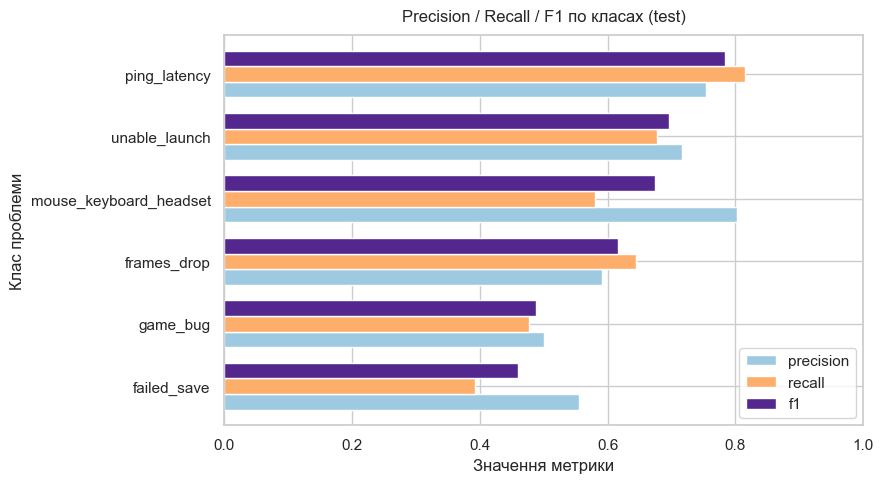

In [80]:
plot_df = per_label[['precision', 'recall', 'f1']].sort_values('f1')

fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind='barh', ax=ax, width=0.75,
             color=['#9ecae1', '#fdae6b', '#54278f'])
ax.set_title('Precision / Recall / F1 по класах (test)', pad=10)
ax.set_xlabel('Значення метрики')
ax.set_ylabel('Клас проблеми')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

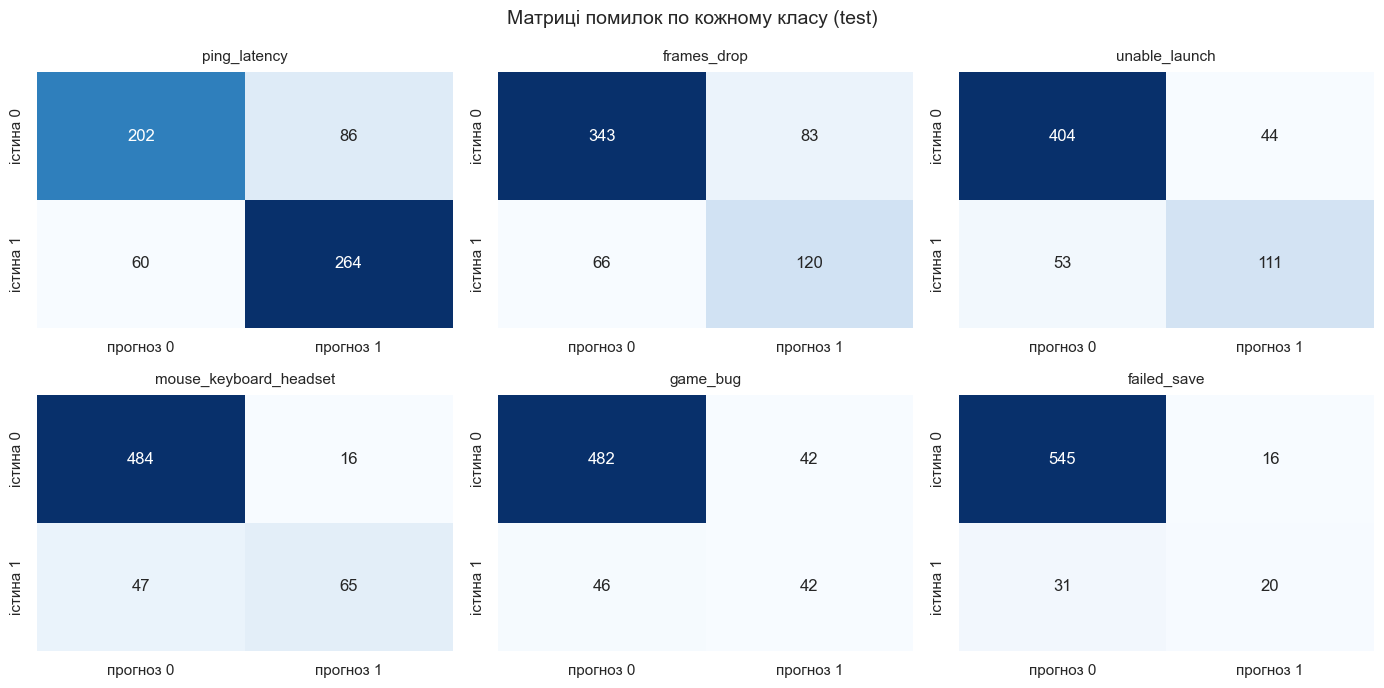

In [81]:
# Матриці помилок окремо для кожного класу
cms = multilabel_confusion_matrix(Y_test, bert_test_pred)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, label, cm in zip(axes.ravel(), LABELS, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['прогноз 0', 'прогноз 1'],
                yticklabels=['істина 0', 'істина 1'])
    ax.set_title(label, fontsize=11, pad=8)

plt.suptitle('Матриці помилок по кожному класу (test)', fontsize=14)
plt.tight_layout()
plt.show()

Якість класифікації помітно відрізняється між окремими класами. Найкращі результати модель демонструє для класів, які мають більш чіткі текстові ознаки, тоді як найнижча якість спостерігається для класів, межі між якими менш однозначні або які представлені меншою кількістю прикладів.

Аналіз окремих метрик показує, що баланс між precision і recall залежить від конкретного класу. Для частини міток модель краще знаходить більшість релевантних прикладів, допускаючи більше хибнопозитивних прогнозів, тоді як для інших працює обережніше, рідше призначаючи відповідну мітку, але пропускаючи більше справжніх випадків. Така поведінка є наслідком індивідуального підбору порогів для кожної мітки.

Окремої уваги заслуговують класи `game_bug` та `failed_save`, для яких модель демонструє найнижчу якість класифікації. Ймовірною причиною є менша кількість прикладів у навчальних даних, а також більша семантична схожість цих категорій з іншими типами проблем. Натомість класи `ping_latency` та `unable_launch` характеризуються найбільш стабільними результатами, що свідчить про наявність більш виражених мовних патернів, які модель успішно розпізнає.

### 13.3 Хибнопозитивні та хибнонегативні прогнози

In [82]:
tp = ((bert_test_pred == 1) & (Y_test == 1)).sum(axis=0)
fp = ((bert_test_pred == 1) & (Y_test == 0)).sum(axis=0)
fn = ((bert_test_pred == 0) & (Y_test == 1)).sum(axis=0)

fp_fn = pd.DataFrame({'TP': tp, 'FP': fp, 'FN': fn}, index=LABELS)
fp_fn['FP/FN'] = (fp_fn['FP'] / fp_fn['FN'].replace(0, np.nan)).round(2)
display(fp_fn)

,TP,FP,FN,FP/FN
ping_latency,264,86,60,1.43
frames_drop,120,83,66,1.26
unable_launch,111,44,53,0.83
mouse_keyboard_headset,65,16,47,0.34
game_bug,42,42,46,0.91
failed_save,20,16,31,0.52


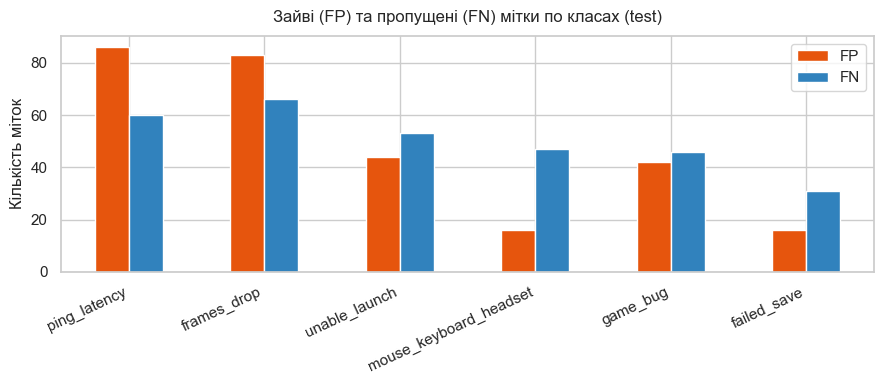

In [83]:
fig, ax = plt.subplots(figsize=(9, 4))
fp_fn[['FP', 'FN']].plot(kind='bar', ax=ax, color=['#e6550d', '#3182bd'])
ax.set_title('Зайві (FP) та пропущені (FN) мітки по класах (test)', pad=10)
ax.set_ylabel('Кількість міток')
ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

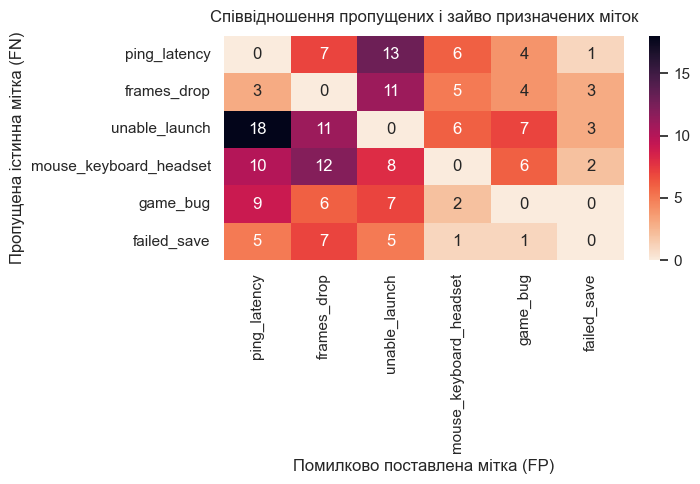

In [84]:
# Які мітки модель ставить замість пропущених: рахуємо пари (пропущена мітка -> зайва мітка) в межах одного й того самого коментаря
miss = ((bert_test_pred == 0) & (Y_test == 1)).astype(int)    # FN по класах
extra = ((bert_test_pred == 1) & (Y_test == 0)).astype(int)   # FP по класах
label_confusion = pd.DataFrame(miss.T.dot(extra), index=LABELS, columns=LABELS)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(label_confusion, annot=True, fmt='d', cmap='rocket_r', ax=ax)
ax.set_title('Співвідношення пропущених і зайво призначених міток', pad=10)
ax.set_xlabel('Помилково поставлена мітка (FP)')
ax.set_ylabel('Пропущена істинна мітка (FN)')

plt.tight_layout()
plt.show()

Аналіз співвідношення хибнопозитивних та хибнонегативних прогнозів підтверджує, що характер помилок відрізняється залежно від класу. Для частини категорій модель частіше призначає зайві мітки, тоді як для інших є більш консервативною і пропускає реальні випадки. Така поведінка є наслідком індивідуального підбору порогів для кожної мітки та прагнення досягти кращого балансу між precision і recall.

Матриця взаємозаміни міток показує, що більшість помилок припадає на семантично близькі або більш поширені категорії. Якщо модель не може впевнено визначити рідкісні чи неоднозначні типи проблем, вона схильна відносити їх до класів, для яких має більше навчальних прикладів або які характеризуються більш вираженими текстовими патернами.

Загалом результати свідчать, що основним джерелом помилок є не випадкові хибні передбачення, а часткове перекриття змісту між окремими класами та природний дисбаланс даних. Це є типовою особливістю задач multi-label класифікації текстів і може бути частково зменшене шляхом збільшення кількості навчальних прикладів для рідкісних категорій або подальшого вдосконалення моделі.

### 13.4 Фактори, що впливають на якість класифікації 

In [85]:
# Помилки залежно від кількості істинних міток у коментарі
by_n = err.groupby('n_true').agg(
    n_comments=('n_err', 'size'),
    exact=('exact_match', 'mean'),
    avg_fp=('n_fp', 'mean'),
    avg_fn=('n_fn', 'mean'),
).round(2)
by_n.columns = ['коментарів', 'частка точного збігу', 'середньо FP', 'середньо FN']
by_n.index.name = 'к-сть істинних міток'
display(by_n)

,коментарів,частка точного збігу,середньо FP,середньо FN
к-сть істинних міток,,,,
1,412,0.58,0.54,0.15
2,123,0.33,0.43,0.72
3,50,0.08,0.16,1.54
4,18,0.00,0.22,2.28
5,9,0.00,0.11,3.67


In [86]:
# Помилки залежно від мови коментаря (топ-6 мов за кількістю прикладів у test)
top_langs = err['lang'].value_counts().head(6).index

by_lang = (err[err['lang'].isin(top_langs)]
           .groupby('lang')
           .agg(n_comments=('n_err', 'size'),
                exact=('exact_match', 'mean'),
                avg_err=('n_err', 'mean'))
           .sort_values('exact', ascending=False)
           .round(2))
by_lang.columns = ['коментарів', 'частка точного збігу', 'середньо помилок']
display(by_lang)

,коментарів,частка точного збігу,середньо помилок
lang,,,
en,424,0.50,0.87
fr,23,0.48,0.74
uk,17,0.47,0.82
es,22,0.41,1.18
pt,47,0.36,1.21
de,11,0.09,1.73


,коментарів,частка точного збігу,середньо помилок
length_bin,,,
≤30,111,0.36,1.28
31–60,144,0.48,0.97
61–120,203,0.51,0.83
>120,154,0.44,0.90


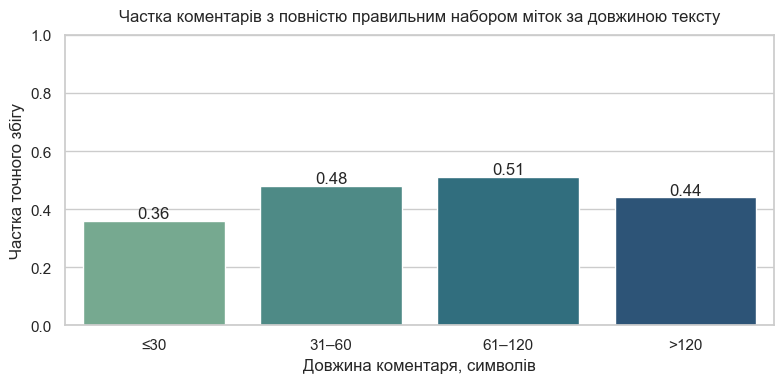

In [87]:
# Помилки залежно від довжини коментаря
err['length_bin'] = pd.cut(err['text_length'], bins=[0, 30, 60, 120, 260],
                           labels=['≤30', '31–60', '61–120', '>120'])

by_len = err.groupby('length_bin', observed=True).agg(
    n_comments=('n_err', 'size'),
    exact=('exact_match', 'mean'),
    avg_err=('n_err', 'mean'),
).round(2)
by_len.columns = ['коментарів', 'частка точного збігу', 'середньо помилок']
display(by_len)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=by_len.index.astype(str), y=by_len['частка точного збігу'], palette='crest', ax=ax)
for i, v in enumerate(by_len['частка точного збігу']):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
ax.set_title('Частка коментарів з повністю правильним набором міток за довжиною тексту', pad=10)
ax.set_xlabel('Довжина коментаря, символів')
ax.set_ylabel('Частка точного збігу')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Аналіз показав, що на кількість помилок моделі найбільше впливають три фактори.

***По-перше***, кількість міток у коментарі. Із зростанням кількості одночасних проблем точність повного збігу поступово знижується, а кількість пропущених міток збільшується. Це свідчить про те, що багатоміткові коментарі є значно складнішими для класифікації, ніж повідомлення з однією проблемою.

***По-друге***, довжина тексту. Найбільше помилок модель допускає на дуже коротких коментарях, де часто бракує контексту для однозначного визначення типу проблеми. Для повідомлень середньої довжини якість є найвищою, тоді як подальше збільшення довжини тексту вже не призводить до помітного покращення результатів.

***По-третє***, мова коментаря. Для найбільш представлених мов якість класифікації залишається близькою. Нижчі результати для окремих мов можуть бути пов’язані з невеликою кількістю прикладів у тестовій вибірці, тому робити однозначні висновки щодо впливу мови на якість моделі наразі недоцільно.

### 13.5 Конкретні приклади помилок

In [88]:
pd.set_option('display.max_colwidth', 80)

# Пропущені мітки (FN): істинна мітка є, але ймовірність моделі нижча за поріг
fn_rows = []
for i in range(len(Y_test)):
    for j in range(len(LABELS)):
        if Y_test[i, j] == 1 and bert_test_pred[i, j] == 0:
            fn_rows.append({'text': X_test[i], 'пропущена мітка': LABELS[j],
                            'ймовірність': bert_test_prob[i, j], 'поріг': th_bert[j]})

fn_examples = pd.DataFrame(fn_rows)
fn_examples['відстань до порогу'] = fn_examples['поріг'] - fn_examples['ймовірність']
fn_examples = fn_examples.sort_values('відстань до порогу', ascending=False)

print(f'Усього пропущених міток (FN): {len(fn_examples)}')
display(fn_examples.head(10).round(3))

Усього пропущених міток (FN): 303


,text,пропущена мітка,ймовірність,поріг,відстань до порогу
180,Can't get to work on steam deck,failed_save,0.078,0.80,0.722
9,Quero meu estorno,failed_save,0.101,0.80,0.699
109,Cuando entro a la app no me deja jugar ni en mi celular ni en mi tv,frames_drop,0.056,0.75,0.694
271,"Could not keep the game connected. tried wifi and ethernet, exactly the same...",frames_drop,0.081,0.75,0.669
273,"Could not keep the game connected. tried wifi and ethernet, exactly the same...",failed_save,0.133,0.80,0.667
261,"Sons of the Forest will not start at all, no servers close to me, 90ms minim...",frames_drop,0.091,0.75,0.659
256,lag makes DayZ unplayable.,unable_launch,0.068,0.70,0.632
6,Quero meu estorno,frames_drop,0.121,0.75,0.629
282,mouse feels awful,unable_launch,0.076,0.70,0.624
187,Lag makes Forza Horzion 5 unplayable.,unable_launch,0.077,0.70,0.623


In [89]:
# Зайві мітки (FP): моделі найбільше "здалося", що проблема є, хоча в розмітці її немає
fp_rows = []
for i in range(len(Y_test)):
    for j in range(len(LABELS)):
        if Y_test[i, j] == 0 and bert_test_pred[i, j] == 1:
            fp_rows.append({'text': X_test[i], 'зайва мітка': LABELS[j],
                            'ймовірність': bert_test_prob[i, j],
                            'істинні мітки': ', '.join(np.array(LABELS)[Y_test[i] == 1])})

fp_examples = pd.DataFrame(fp_rows).sort_values('ймовірність', ascending=False)

print(f'Усього зайвих міток (FP): {len(fp_examples)}')
display(fp_examples.head(10).round(3))

Усього зайвих міток (FP): 287


,text,зайва мітка,ймовірність,істинні мітки
72,Controle não estava respondendo,mouse_keyboard_headset,0.991,game_bug
116,stuttery,frames_drop,0.987,"ping_latency, mouse_keyboard_headset"
159,Problem with controller support on Nvidia Shield as well,mouse_keyboard_headset,0.985,"ping_latency, frames_drop, unable_launch"
91,Impossible to play I whant my money back,unable_launch,0.984,ping_latency
30,"I am not sure if its on your end or my end, but I am playing on Starlink and...",frames_drop,0.983,ping_latency
203,"Постійні баги, фрізи, це з кабелем інтерету під'єданим до ноутбуку в той час...",frames_drop,0.981,"ping_latency, mouse_keyboard_headset"
103,Couldn’t type @ on rockstar to launch,unable_launch,0.980,mouse_keyboard_headset
87,"Мило, тупо мило, дякую за -400 гривень.",frames_drop,0.979,ping_latency
223,Always an error connection even with good ping,ping_latency,0.979,unable_launch
181,Mainly had problems with monster hunter wilds. Lots of connection issues.,frames_drop,0.979,"game_bug, failed_save"


In [90]:
# Коментарі, де модель помилилась найбільше (3+ помилки одразу)
worst = err[err['n_err'] >= 3].sort_values('n_err', ascending=False).head(8)
display(worst[['text', 'lang', 'n_true', 'n_pred', 'n_fp', 'n_fn']])

pd.reset_option('display.max_colwidth')

,text,lang,n_true,n_pred,n_fp,n_fn
217,"The settings, especially the language, are not saved. For some users, the lo...",en,2,4,4,2
13,Quero meu estorno,pt,5,1,1,5
86,Es una estafa. Todo el rato con requisitos de inicio de steam y encima me sa...,es,1,4,4,1
558,"Have to remap all keys on every session, could not keep the game connected, ...",en,5,1,0,4
536,"Could not keep the game connected. tried wifi and ethernet, exactly the same...",en,5,1,0,4
488,Stutters in Hogwarts Legacy,en,4,2,1,3
345,ff,cy,3,1,1,3
300,Ne correspond pas a mes attentes,pt,5,1,0,4


Аналіз конкретних прикладів дозволяє краще зрозуміти природу помилок моделі.

Серед хибнопозитивних прогнозів трапляються випадки, коли передбачена моделлю мітка виглядає логічною та семантично близькою до істинної. Це свідчить про те, що частина помилок може бути пов’язана не лише з обмеженнями моделі, а й з неоднозначністю або неточностями у розмітці даних.

Для хибнонегативних прогнозів характерно, що відповідні ймовірності залишаються нижчими за встановлений поріг прийняття рішення. Найчастіше це стосується рідкісних класів або коротких повідомлень із недостатньою кількістю контексту.

Найбільша кількість помилок спостерігається у дуже коротких коментарях із кількома одночасними мітками. Такі приклади є складними як для моделі, так і для процесу розмітки, що підтверджує результати попереднього аналізу залежності якості класифікації від характеристик коментарів.

### 13.6 Наскільки результат залежить від підібраних порогів

Пороги для кожного класу підбирались на validation-вибірці, а потім без змін застосовувались до test.
Перевіримо, скільки якості це дає порівняно зі стандартним порогом 0.5 і наскільки далеко отриманий
результат від теоретично найкращого (пороги, підібрані безпосередньо на test — на практиці недосяжні,
бо тестові мітки моделі невідомі).

In [91]:
th_test_opt = tune_thresholds(Y_test, bert_test_prob)

f1_default = f1_score(Y_test, (bert_test_prob >= 0.5).astype(int), average='macro', zero_division=0)
f1_val_th = f1_score(Y_test, (bert_test_prob >= th_bert).astype(int), average='macro', zero_division=0)
f1_test_th = f1_score(Y_test, (bert_test_prob >= th_test_opt).astype(int), average='macro', zero_division=0)

display(pd.DataFrame({
    'варіант порогів': ['0.5 (без підбору)', 'підібрані на validation', 'оптимальні на test (недосяжні)'],
    'macro-F1 (test)': [round(f1_default, 3), round(f1_val_th, 3), round(f1_test_th, 3)],
}))

,варіант порогів,macro-F1 (test)
0,0.5 (без підбору),0.581
1,підібрані на validation,0.620
2,оптимальні на test (недосяжні),0.624


In [92]:
# Порівняння самих порогів: підібрані на validation vs оптимальні на test
display(pd.DataFrame({
    'поріг з validation': th_bert,
    'оптимальний на test': th_test_opt,
    'різниця': np.abs(th_bert - th_test_opt),
}, index=LABELS).round(3))

,поріг з validation,оптимальний на test,різниця
ping_latency,0.450,0.400,0.050
frames_drop,0.750,0.750,0.000
unable_launch,0.700,0.675,0.025
mouse_keyboard_headset,0.525,0.550,0.025
game_bug,0.550,0.825,0.275
failed_save,0.800,0.800,0.000


Підбір індивідуальних порогів для кожного класу дозволив покращити якість multi-label класифікації порівняно з використанням стандартного порога. Це підтверджує, що різні класи потребують різної чутливості моделі через відмінності в їхній поширеності та складності розпізнавання.

Пороги, підібрані на validation-вибірці, забезпечили результат, близький до теоретично найкращого, який можна було б отримати лише за наявності правильних відповідей на test-вибірці. Це свідчить, що обраний підхід добре узагальнюється на нових даних і не потребує додаткового налаштування після завершення навчання.

Хоча для окремих класів оптимальні пороги можуть відрізнятися між validation і test-вибірками, це не має істотного впливу на загальну якість моделі. Отже, використання порогів, підібраних на validation-вибірці, є практичним і методологічно коректним способом підвищення якості класифікації.

## 14. Висновки

### 14.1 Яка модель працює найкраще і чому

За результатами проведених експериментів найкращу загальну якість показала **fine-tuned multilingual DistilBERT**, тому саме ця модель була обрана як фінальна. Її перевага пояснюється здатністю враховувати контекст повідомлення та працювати із текстами різними мовами без жорсткої прив’язки до окремих слів чи фраз.

Водночас дослідження показало, що різниця між сучасними підходами виявилася меншою, ніж можна було очікувати. **Zero-shot LLM** продемонструвала результат, близький до навченої моделі, навіть без додаткового навчання, а класичні **TF-IDF** моделі також забезпечили конкурентну якість за значно менших обчислювальних витрат.

Найважливішим результатом роботи стало те, що основним фактором, який обмежує якість класифікації, виявилась не архітектура моделі, а характеристики самого набору даних: шум у розмітці, короткі коментарі та значне семантичне перекриття між окремими класами.

### 14.2 Практичні інсайти

Проведений аналіз дозволив сформулювати кілька практичних висновків.

* **Текст справді несе сильний сигнал.** Найбільш інформативним джерелом для класифікації виявився сам текст коментаря. Навіть короткі повідомлення у більшості випадків містять достатньо інформації для визначення типу технічної проблеми.

* **Головний драйвер відтоку — мережева затримка.** Найчастіше користувачі повідомляють про проблеми із затримкою мережі, яка також часто супроводжує інші категорії несправностей. Це підтверджує, що мережева нестабільність є одним із ключових факторів відтоку користувачів хмарного геймінгу.

* **Стеля якості визначається даними, а не моделлю.** Усі сім підходів — від TF-IDF до трансформера й LLM — укладаються у вузький діапазон macro-F1. Це типова ознака того, що обмежувальним чинником є шум розмітки, короткі тексти та семантичне перетинання класів, а не архітектура моделі.

* **Прості моделі майже не поступаються складним.** Використання складніших моделей не гарантує пропорційного приросту якості. У даному наборі даних класичні TF-IDF моделі виявилися конкурентними порівняно з трансформерами.

* **Характер помилок залежить від вибору порогів.** Після підбору порогів модель прагне знайти баланс між пропущеними та зайвими мітками. Це дозволяє адаптувати її поведінку до конкретного сценарію використання: для аналітичних систем можна надавати перевагу повноті, а для автоматичного створення заявок — підвищувати пороги, щоб зменшити кількість хибних спрацювань.

### 14.3 Як це може використовуватись у бізнесі

* **Пріоритезація інженерного беклогу.** Автоматичне тегування коментарів користувачів дозволяє швидко визначати, які технічні проблеми найчастіше призводять до відтоку, без необхідності ручного аналізу великої кількості повідомлень.
* **Маршрутизація фідбеку.** Передбачені мітки природно відповідають зонам відповідальності різних команд (мережа, стрімінг, інтеграція ігор, периферія, хмарні збереження), що дає змогу автоматично спрямовувати звернення до відповідних фахівців.
* **Моніторинг у часі.** Аналіз динаміки міток дозволяє оперативно виявляти появу нових технічних проблем після релізів, змін інфраструктури або в окремих регіонах.
* **Вибір моделі залежно від сценарію використання.** Якщо ключовими є швидкість роботи, простота підтримки та низькі обчислювальні витрати, доцільно використовувати класичні моделі. Якщо ж потрібна максимальна якість локальної моделі або планується подальше накопичення навчальних даних, доцільніше застосовувати трансформери. Для сценаріїв без власної розмітки перспективним варіантом можуть бути LLM через API.
* **Налаштування порогів відповідно до бізнес-задачі.** Пороги прийняття рішення варто підбирати залежно від сценарію використання: для аналітичних звітів можна використовувати більш чутливі налаштування, тоді як для автоматичного створення заявок доцільніше підвищувати пороги, щоб зменшити кількість хибних спрацьовувань.

### 14.4 Обмеження

* **Шум у розмітці.** Мітки встановлюються самими користувачами під час відписки, тому вони не завжди є послідовними або взаємовиключними. Аналіз прикладів показав, що частина випадків, які модель класифікує інакше, імовірно пов’язана не з помилками моделі, а з неточностями початкової розмітки.
* **Короткі тексти.** Значна частина коментарів містить дуже мало інформації, що ускладнює визначення конкретної причини проблеми навіть для сучасних мовних моделей.
* **Дисбаланс класів.** Деякі категорії представлені значно меншою кількістю прикладів, через що модель гірше навчається їх розпізнавати, а оцінка якості суттєво залежить від рідкісних класів.
* **Підбір гіперпараметрів і порогів на одній validation-вибірці.** У роботі використовувалося одне розбиття даних, тому результати на validation можуть бути дещо оптимістичними. Остаточна оцінка якості виконувалася на окремій test-вибірці.
* **Один випадковий поділ даних.** Експерименти проводилися для одного розбиття вибірки та одного значення випадкового зерна, тому невеликі відмінності між моделями можуть бути зумовлені випадковими коливаннями.
* **Обмежене дослідження LLM.** Великі мовні моделі оцінювалися лише в режимі zero-shot. Питання вартості використання, затримки відповіді, масштабованості та інших практичних аспектів їхнього застосування в межах цієї роботи окремо не досліджувалися.

### 14.5 Що можна покращити далі

1. **Якість даних — найбільший потенціал.** Перерозмітити вручну підвибірку (наприклад, 500 коментарів) і використати її як «золоту» test-вибірку. Це дасть чеснішу оцінку і, судячи з аналізу помилок, помітно вищі метрики.
2. **Чесніша схема оцінювання.** Крос-валідація замість одного розбиття та підбір порогів на окремій частині даних, відмінній від тієї, на якій вимірюється якість.
3. **Сильніші мультимовні моделі.** XLM-RoBERTa або mDeBERTa замість DistilBERT, а також ансамбль BERT + TF-IDF + LLM: ці моделі помиляються по-різному, тому їх поєднання має дати приріст.
4. **Робота з LLM.** Few-shot промпт із прикладами з train-вибірки, використання logprobs замість бінарних відповідей (щоб можна було підбирати пороги), а також дистиляція: LLM як «вчитель» для псевдорозмітки більшого обсягу даних.

## 15. Збереження фінальної моделі для деплою

Щоб модель можна було використовувати поза нотбуком, зберігаємо три речі: ваги фінальної моделі,
токенайзер і конфіг для інференсу. У конфіг обовʼязково потрапляють **пороги, підібрані на
validation** — без них прогнози рахуватимуться зі стандартним порогом 0.5, а це помітно гірша
якість (macro-F1 0.581 замість 0.620 на test).

In [93]:
# Зберігаємо фінальну модель, токенайзер і конфіг для інференсу
SAVE_DIR = Path('../models/bert_multilabel')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

bert_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Пороги, мітки й довжина послідовності — усе, що потрібно для правильного інференсу
inference_config = {
    'labels': LABELS,
    'thresholds': th_bert.tolist(),
    'max_len': MAX_LEN,
    'base_checkpoint': CKPT,
    'learning_rate': best_lr,
    'val_macro_f1': round(float(best_bert_f1), 4),
}
with open(SAVE_DIR / 'inference_config.json', 'w') as f:
    json.dump(inference_config, f, indent=2, ensure_ascii=False)

print(f'Збережено у {SAVE_DIR.resolve()}\n')
for file in sorted(SAVE_DIR.iterdir()):
    print(f'  {file.name:28} {file.stat().st_size / 1e6:7.1f} МБ')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Збережено у /Users/dasabilan/Desktop/DS/Курс ML/КУРС/HomeTasks/DL_project_my_for_AI/models/bert_multilabel

  config.json                      0.0 МБ
  inference_config.json            0.0 МБ
  model.safetensors              541.3 МБ
  tokenizer.json                   2.9 МБ
  tokenizer_config.json            0.0 МБ
